In [17]:
## Installing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import sympy

In [18]:
## Defining Function in python
x_sym = sympy.symbols('x')

f1 = sympy.sin(x_sym)
f2 = sympy.exp(x_sym)
f3 = 7*x_sym**6 + 5*x_sym**4 + 2*x_sym**3 + 9*x_sym
f4 = 8*x_sym + 2
f1,f2,f3,f4

(sin(x), exp(x), 7*x**6 + 5*x**4 + 2*x**3 + 9*x, 8*x + 2)

In [19]:
## create the derivative by symbolially differentiate
# Exact derivative
d2f_dx2_1_exact = sympy.diff(f1,x_sym,2)
d2f_dx2_2_exact = sympy.diff(f2,x_sym,2)
d2f_dx2_3_exact = sympy.diff(f3,x_sym,2)
d2f_dx2_4_exact = sympy.diff(f4,x_sym,2)
d2f_dx2_1_exact,d2f_dx2_2_exact,d2f_dx2_3_exact,d2f_dx2_4_exact

(-sin(x), exp(x), 6*x*(35*x**3 + 10*x + 2), 0)

# Now the Defining the 2nd order derivatives using CDS, FDS for different cases of accuracy

In [20]:
## case a) For the 2nd order CDS
def CDS_2_order(f,x,h):
  return  (f(x+h) - 2*f(x) + f(x-h)) / h**2


## case b) For 3rd order FDS
def FDS_3_order(f,x,h):
    return (
         (35/12)*f(x)
        - (26/3)*f(x+h)
        + (19/2)*f(x+2*h)
        - (14/3)*f(x+3*h)
        + (11/12)*f(x+4*h)
    ) / h**2

## case c) For 4rth order CDS
def central_4th(f, x, h):
    return (
        -f(x+2*h)
        + 16*f(x+h)
        - 30*f(x)
        + 16*f(x-h)
        - f(x-2*h)
    ) / (12*h**2)


## Now compute the 2nd order derivatives for exact and numerical way both, assuming  our functions vary from 0 to 1

In [21]:
## Compute the exact derivatives
delta_xs = [ 0.1, 0.01, 0.001, 0.0001]

func1 = sympy.lambdify(x_sym,f1,'numpy')
func2 = sympy.lambdify(x_sym,f2,'numpy')
func3 = sympy.lambdify(x_sym,f3,'numpy')
func4 = sympy.lambdify(x_sym,f4,'numpy')

d2f_func1 = sympy.lambdify(x_sym, d2f_dx2_1_exact, 'numpy')
d2f_func2 = sympy.lambdify(x_sym, d2f_dx2_2_exact, 'numpy')
d2f_func3 = sympy.lambdify(x_sym, d2f_dx2_3_exact, 'numpy')
d2f_func4 = sympy.lambdify(x_sym, d2f_dx2_4_exact, 'numpy')
#d2f_dx2_1_exact_array = d2f_dx2_1_exact()
X=np.linspace(0,1,10000)
d2f_dx2_1_exact_array = d2f_func1(X)
d2f_dx2_2_exact_array = d2f_func2(X)
d2f_dx2_3_exact_array = d2f_func3(X)
d2f_dx2_4_exact_array = d2f_func4(X)



a--> case a : 2nd order CDS
b--> case b: 3rd order FDS
c--> case c: 4th order CDS

ai--> 'i' means for what spacing

b2 --> 3rd order FDS and dx = 0.01

### 2nd order CDS for all the function


In [22]:


####### ------     spacing is '0.1' means case 'a1' ------    ###########33

dx = 0.1 #delta_xs(i)
N = int(10/dx) +1
xs = np.linspace(0,1,N)
## Initialize some storage arrays for plottig  Numerical ones

# for the First function (sinx)
d2f_dx2_1_exact_array_a1 = np.zeros_like(xs) # store exact values
d2f_dx2_1_num_a1 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_1_err_a1 = np.zeros_like(xs) # store errors
# for the 2nd function (ex)
d2f_dx2_2_exact_array_a1 = np.zeros_like(xs)
d2f_dx2_2_num_a1 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_2_err_a1 = np.zeros_like(xs)
# for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
d2f_dx2_3_exact_array_a1 = np.zeros_like(xs)
d2f_dx2_3_num_a1 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_3_err_a1 = np.zeros_like(xs)
# For 4rth function (8*x + 2)
d2f_dx2_4_exact_array_a1 = np.zeros_like(xs)
d2f_dx2_4_num_a1 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_4_err_a1 = np.zeros_like(xs)

# For 2nd order CDS it will start form first point as i-1 is out side boundary
for i in range(1,len(xs)-1):

  # for the First function (sinx)
    exact_val =  d2f_func1(xs[i]) #calculate exact value

    d2f_dx2_1_exact_array_a1[i] = exact_val
    d2f_dx2_1_num_a1[i] = CDS_2_order(func1, xs[i], dx)
    d2f_dx2_1_err_a1[i] = d2f_dx2_1_num_a1[i] - exact_val

    # for the 2nd function (ex)
    exact_val =  d2f_func2(xs[i]) #calculate exact value

    d2f_dx2_2_exact_array_a1[i] = exact_val
    d2f_dx2_2_num_a1[i] = CDS_2_order(func2, xs[i], dx)
    d2f_dx2_2_err_a1[i] = d2f_dx2_2_num_a1[i] - exact_val

    # for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
    exact_val =  d2f_func3(xs[i]) #calculate exact value

    d2f_dx2_3_exact_array_a1[i] = exact_val
    d2f_dx2_3_num_a1[i] = CDS_2_order(func3, xs[i], dx)
    d2f_dx2_3_err_a1[i] = d2f_dx2_3_num_a1[i] - exact_val


    # For 4rth function (8*x + 2)
    exact_val =  d2f_func4(xs[i]) #calculate exact value

    d2f_dx2_4_exact_array_a1[i] = exact_val
    d2f_dx2_4_num_a1[i] = CDS_2_order(func4, xs[i], dx)
    d2f_dx2_4_err_a1[i] = d2f_dx2_4_num_a1[i] - exact_val






##----------      spacing is '0.01' means case 'a2'  --------- ####

dx = 0.01 #delta_xs(i)
N = int(10/dx) +1
xs = np.linspace(0,1,N)
## Initialize some storage arrays for plottig  Numerical ones

# for the First function (sinx)
d2f_dx2_1_exact_array_a2 = np.zeros_like(xs) # store exact values
d2f_dx2_1_num_a2 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_1_err_a2 = np.zeros_like(xs) # store errors
# for the 2nd function (ex)
d2f_dx2_2_exact_array_a2 = np.zeros_like(xs)
d2f_dx2_2_num_a2 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_2_err_a2 = np.zeros_like(xs)
# for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
d2f_dx2_3_exact_array_a2 = np.zeros_like(xs)
d2f_dx2_3_num_a2 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_3_err_a2 = np.zeros_like(xs)
# For 4rth function (8*x + 2)
d2f_dx2_4_exact_array_a2 = np.zeros_like(xs)
d2f_dx2_4_num_a2 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_4_err_a2 = np.zeros_like(xs)

# For 2nd order CDS it will start form first point as i-1 is out side boundary
for i in range(1,len(xs)-1):

  # for the First function (sinx)
    exact_val =  d2f_func1(xs[i]) #calculate exact value

    d2f_dx2_1_exact_array_a2[i] = exact_val
    d2f_dx2_1_num_a2[i] = CDS_2_order(func1, xs[i], dx)
    d2f_dx2_1_err_a2[i] = d2f_dx2_1_num_a2[i] - exact_val

    # for the 2nd function (ex)
    exact_val =  d2f_func2(xs[i]) #calculate exact value

    d2f_dx2_2_exact_array_a2[i] = exact_val
    d2f_dx2_2_num_a2[i] = CDS_2_order(func2, xs[i], dx)
    d2f_dx2_2_err_a2[i] = d2f_dx2_2_num_a2[i] - exact_val

    # for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
    exact_val =  d2f_func3(xs[i]) #calculate exact value

    d2f_dx2_3_exact_array_a2[i] = exact_val
    d2f_dx2_3_num_a2[i] = CDS_2_order(func3, xs[i], dx)
    d2f_dx2_3_err_a2[i] = d2f_dx2_3_num_a2[i] - exact_val


    # For 4rth function (8*x + 2)
    exact_val =  d2f_func4(xs[i]) #calculate exact value

    d2f_dx2_4_exact_array_a2[i] = exact_val
    d2f_dx2_4_num_a2[i] = CDS_2_order(func4, xs[i], dx)
    d2f_dx2_4_err_a2[i] = d2f_dx2_4_num_a2[i] - exact_val







##----------      spacing is '0.001' means case 'a3'  --------- ####


dx = 0.001 #delta_xs(i)
N = int(10/dx) +1
xs = np.linspace(0,1,N)
## Initialize some storage arrays for plottig  Numerical ones

# for the First function (sinx)
d2f_dx2_1_exact_array_a3 = np.zeros_like(xs) # store exact values
d2f_dx2_1_num_a3 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_1_err_a3 = np.zeros_like(xs) # store errors
# for the 2nd function (ex)
d2f_dx2_2_exact_array_a3 = np.zeros_like(xs)
d2f_dx2_2_num_a3 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_2_err_a3 = np.zeros_like(xs)
# for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
d2f_dx2_3_exact_array_a3 = np.zeros_like(xs)
d2f_dx2_3_num_a3 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_3_err_a3 = np.zeros_like(xs)
# For 4rth function (8*x + 2)
d2f_dx2_4_exact_array_a3 = np.zeros_like(xs)
d2f_dx2_4_num_a3 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_4_err_a3 = np.zeros_like(xs)

# For 2nd order CDS it will start form first point as i-1 is out side boundary
for i in range(1,len(xs)-1):

  # for the First function (sinx)
    exact_val =  d2f_func1(xs[i]) #calculate exact value

    d2f_dx2_1_exact_array_a3[i] = exact_val
    d2f_dx2_1_num_a3[i] = CDS_2_order(func1, xs[i], dx)
    d2f_dx2_1_err_a3[i] = d2f_dx2_1_num_a3[i] - exact_val

    # for the 2nd function (ex)
    exact_val =  d2f_func2(xs[i]) #calculate exact value

    d2f_dx2_2_exact_array_a3[i] = exact_val
    d2f_dx2_2_num_a3[i] = CDS_2_order(func2, xs[i], dx)
    d2f_dx2_2_err_a3[i] = d2f_dx2_2_num_a3[i] - exact_val

    # for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
    exact_val =  d2f_func3(xs[i]) #calculate exact value

    d2f_dx2_3_exact_array_a3[i] = exact_val
    d2f_dx2_3_num_a3[i] = CDS_2_order(func3, xs[i], dx)
    d2f_dx2_3_err_a3[i] = d2f_dx2_3_num_a3[i] - exact_val


    # For 4rth function (8*x + 2)
    exact_val =  d2f_func4(xs[i]) #calculate exact value

    d2f_dx2_4_exact_array_a3[i] = exact_val
    d2f_dx2_4_num_a3[i] = CDS_2_order(func4, xs[i], dx)
    d2f_dx2_4_err_a3[i] = d2f_dx2_4_num_a3[i] - exact_val




    ##----------      spacing is '0.0001' means case 'a4'  --------- ####


dx = 0.0001 #delta_xs(i)
N = int(10/dx) +1
xs = np.linspace(0,1,N)
## Initialize some storage arrays for plottig  Numerical ones

# for the First function (sinx)
d2f_dx2_1_exact_array_a4 = np.zeros_like(xs) # store exact values
d2f_dx2_1_num_a4 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_1_err_a4 = np.zeros_like(xs) # store errors
# for the 2nd function (ex)
d2f_dx2_2_exact_array_a4 = np.zeros_like(xs)
d2f_dx2_2_num_a4 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_2_err_a4 = np.zeros_like(xs)
# for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
d2f_dx2_3_exact_array_a4 = np.zeros_like(xs)
d2f_dx2_3_num_a4 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_3_err_a4 = np.zeros_like(xs)
# For 4rth function (8*x + 2)
d2f_dx2_4_exact_array_a4 = np.zeros_like(xs)
d2f_dx2_4_num_a4 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_4_err_a4 = np.zeros_like(xs)

# For 2nd order CDS it will start form first point as i-1 is out side boundary
for i in range(1,len(xs)-1):

  # for the First function (sinx)
    exact_val =  d2f_func1(xs[i]) #calculate exact value

    d2f_dx2_1_exact_array_a4[i] = exact_val
    d2f_dx2_1_num_a4[i] = CDS_2_order(func1, xs[i], dx)
    d2f_dx2_1_err_a4[i] = d2f_dx2_1_num_a4[i] - exact_val

    # for the 2nd function (ex)
    exact_val =  d2f_func2(xs[i]) #calculate exact value

    d2f_dx2_2_exact_array_a4[i] = exact_val
    d2f_dx2_2_num_a4[i] = CDS_2_order(func2, xs[i], dx)
    d2f_dx2_2_err_a4[i] = d2f_dx2_2_num_a4[i] - exact_val

    # for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
    exact_val =  d2f_func3(xs[i]) #calculate exact value

    d2f_dx2_3_exact_array_a4[i] = exact_val
    d2f_dx2_3_num_a4[i] = CDS_2_order(func3, xs[i], dx)
    d2f_dx2_3_err_a4[i] = d2f_dx2_3_num_a4[i] - exact_val


    # For 4rth function (8*x + 2)
    exact_val =  d2f_func4(xs[i]) #calculate exact value

    d2f_dx2_4_exact_array_a4[i] = exact_val
    d2f_dx2_4_num_a4[i] = CDS_2_order(func4, xs[i], dx)
    d2f_dx2_4_err_a4[i] = d2f_dx2_4_num_a4[i] - exact_val



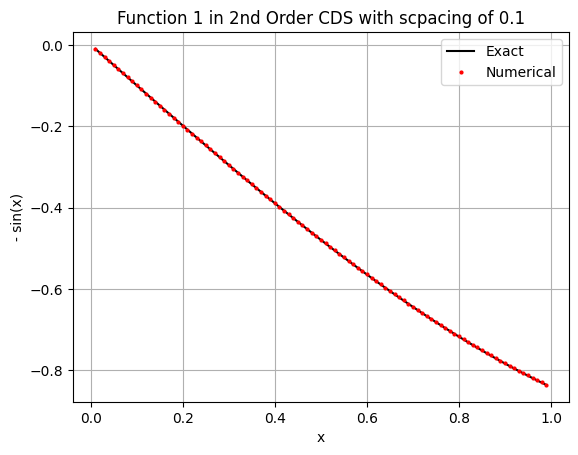

L∞ norm = 0.0006964561275266679
L2 norm = 0.004321807484963931
Root Mean square =  0.00043435799526590595


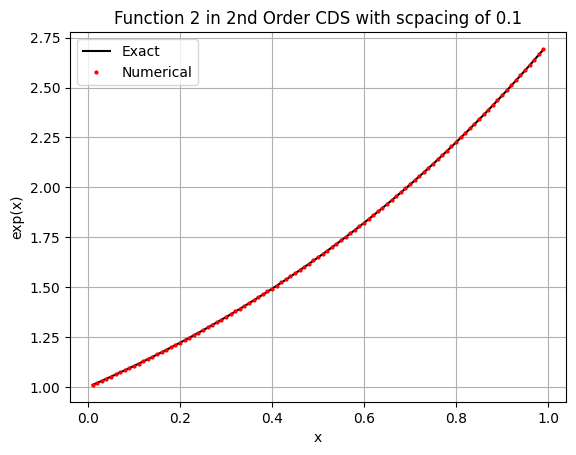

L∞ norm = 0.0022434430923263804
L2 norm = 0.014801444587790712
Root Mean square =  0.0014876011531193467


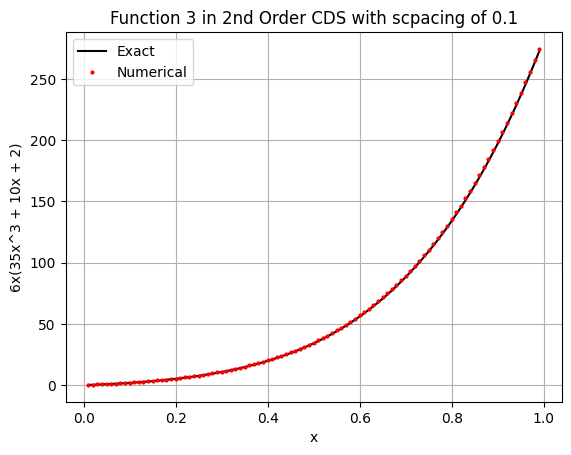

L∞ norm = 2.159610000000214
L2 norm = 10.050441965057912
Root Mean square =  1.0101074234951306


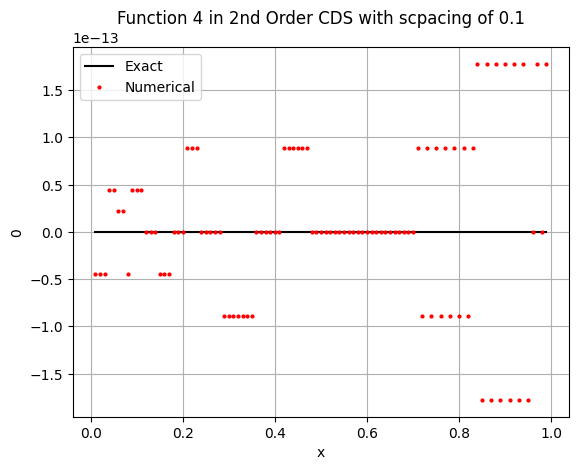

L∞ norm = 1.7763568394002502e-13
L2 norm = 8.337767523300325e-13
Root Mean square =  8.37977165575697e-14
 
 Error calculation for function 1 in spacing 0.01
L∞ norm = 7.007728187513607e-06
L2 norm = 0.00013751764161633076
Root Mean square =  4.350865636572231e-06
 
 Error calculation for function 2 in spacing 0.01
L∞ norm = 2.2629775144000774e-05
L2 norm = 0.00047069362511839975
Root Mean square =  1.4892087261028614e-05
 
 Error calculation for function 3 in spacing 0.01
L∞ norm = 0.021958160866006438
L2 norm = 0.3208736367653364
Root Mean square =  0.010151992598733403

 Error calculation for function 4 in spacing 0.01
L∞ norm = 3.552713678800501e-11
L2 norm = 3.9142880491419e-10
Root Mean square =  1.2384259331738284e-11
 
 Error calculation for function 1 in spacing 0.01
L∞ norm = 7.017659386931996e-08
L2 norm = 4.3512381260519515e-06
Root Mean square =  4.3514557042767564e-08
 
 Error calculation for function 2 in spacing 0.01
L∞ norm = 2.2674059874105978e-07
L2 norm = 1.48933447

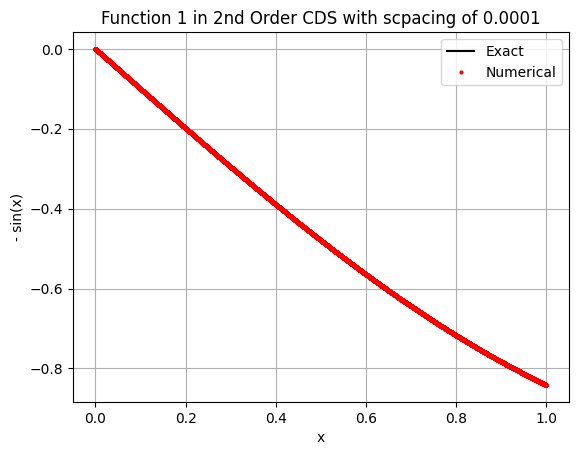

L∞ norm = 2.1919275505766223e-08
L2 norm = 1.8552891453631948e-06
Root Mean square =  5.866968752452015e-09


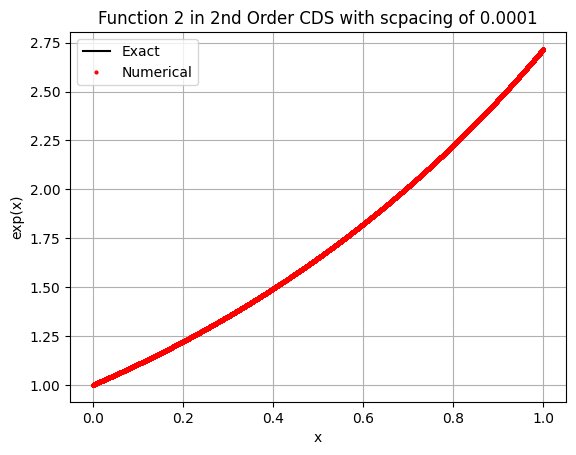

L∞ norm = 9.037436710102043e-08
L2 norm = 6.929913166841885e-06
Root Mean square =  2.1914419166780564e-08


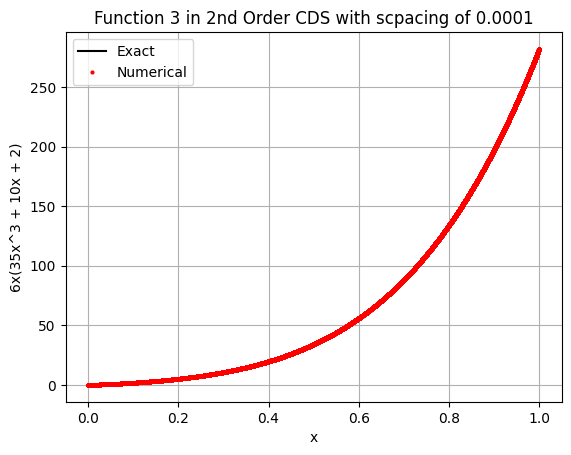

L∞ norm = 3.707363191551849e-06
L2 norm = 0.00032532295790572844
Root Mean square =  1.0287666659713726e-06


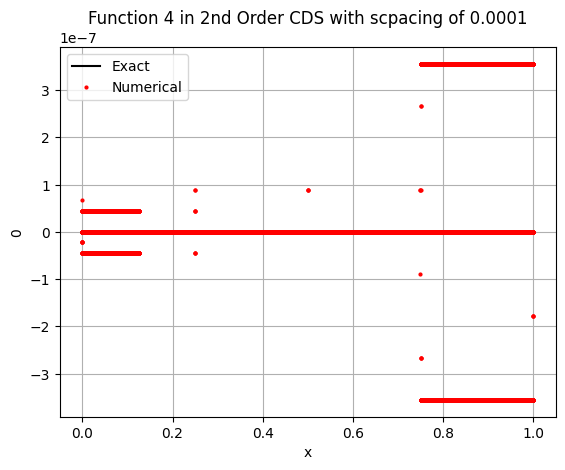

L∞ norm = 3.552713678800501e-07
L2 norm = 3.9860327837108556e-05
Root Mean square =  1.260500544981243e-07


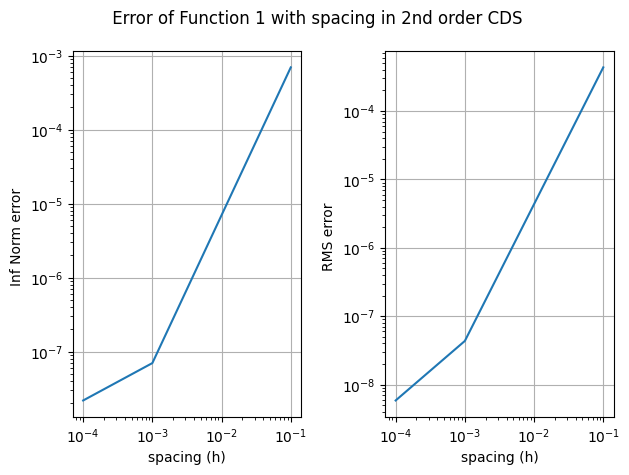

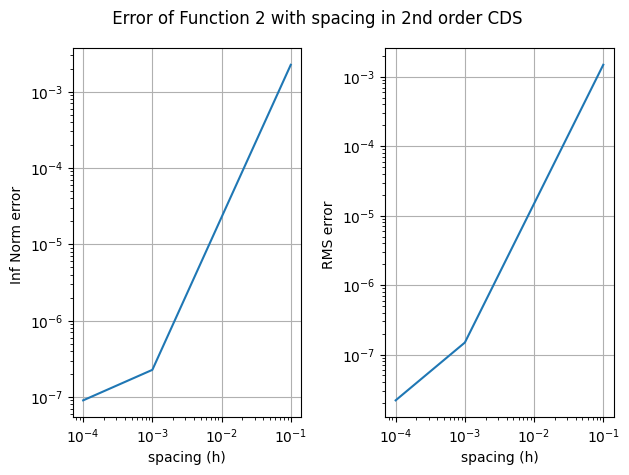

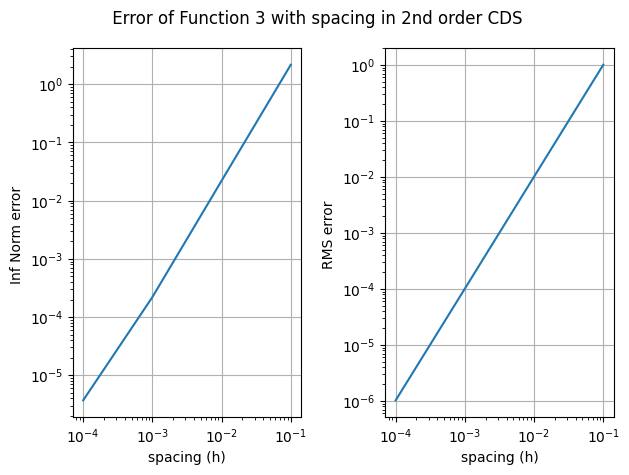

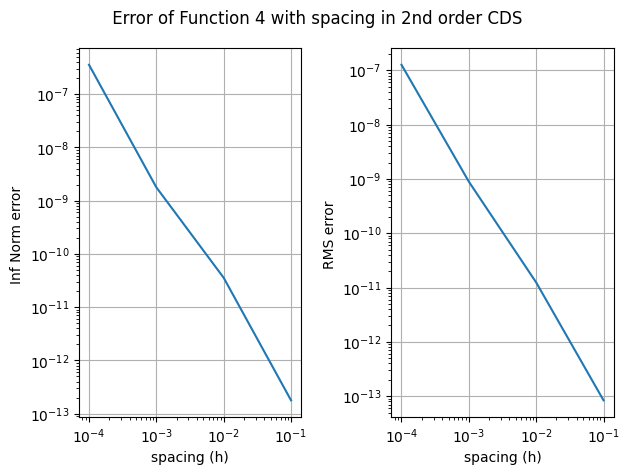

In [23]:
## Visulization

#### ------------------   case a1: 2nd order CDS & spacing is 0.1 ----------#
dx = 0.1 #delta_xs(i)
N = int(10/dx) +1
xs = np.linspace(0,1,N)

plt.plot(xs[1:-1],d2f_dx2_1_exact_array_a1[1:-1],'k-',label="Exact" )
plt.plot(xs[1:-1],d2f_dx2_1_num_a1[1:-1],'ro', markersize=2,label="Numerical" )
plt.legend()
plt.xlabel('x')
plt.ylabel('- sin(x)')
plt.title('Function 1 in 2nd Order CDS with scpacing of 0.1')
plt.grid(True)
plt.show()

# error of funcn 1

Linf_f1_a1 = np.max(np.abs(d2f_dx2_1_err_a1[1:-1])) # Linf norm
L2_f1_a1 = np.sqrt(np.sum((d2f_dx2_1_err_a1[1:-1])**2)) # L2 norm
RMSE_f1_a1 = np.sqrt(np.mean((d2f_dx2_1_err_a1[1:-1])**2))
print("L∞ norm =", Linf_f1_a1)
print("L2 norm =", L2_f1_a1)
print("Root Mean square = ", RMSE_f1_a1)



plt.plot(xs[1:-1],d2f_dx2_2_exact_array_a1[1:-1],'k-',label="Exact" )
plt.plot(xs[1:-1],d2f_dx2_2_num_a1[1:-1],'ro', markersize=2,label="Numerical" )
plt.legend()
plt.xlabel('x')
plt.ylabel('exp(x)')
plt.title('Function 2 in 2nd Order CDS with scpacing of 0.1')
plt.grid(True)
plt.show()

Linf_f2_a1 = np.max(np.abs(d2f_dx2_2_err_a1[1:-1])) # Linf norm
L2_f2_a1 = np.sqrt(np.sum((d2f_dx2_2_err_a1[1:-1])**2)) # L2 norm
RMSE_f2_a1 = np.sqrt(np.mean((d2f_dx2_2_err_a1[1:-1])**2))
print("L∞ norm =", Linf_f2_a1)
print("L2 norm =", L2_f2_a1)
print("Root Mean square = ", RMSE_f2_a1)




plt.plot(xs[1:-1],d2f_dx2_3_exact_array_a1[1:-1],'k-',label="Exact" )
plt.plot(xs[1:-1],d2f_dx2_3_num_a1[1:-1],'ro', markersize=2,label="Numerical" )
plt.legend()
plt.xlabel('x')
plt.ylabel('6x(35x^3 + 10x + 2)')
plt.title('Function 3 in 2nd Order CDS with scpacing of 0.1')
plt.grid(True)
plt.show()

Linf_f3_a1 = np.max(np.abs(d2f_dx2_3_err_a1[1:-1])) # Linf norm
L2_f3_a1 = np.sqrt(np.sum((d2f_dx2_3_err_a1[1:-1])**2)) # L2 norm
RMSE_f3_a1 = np.sqrt(np.mean((d2f_dx2_3_err_a1[1:-1])**2))
print("L∞ norm =", Linf_f3_a1)
print("L2 norm =", L2_f3_a1)
print("Root Mean square = ", RMSE_f3_a1)



plt.plot(xs[1:-1],d2f_dx2_4_exact_array_a1[1:-1],'k-',label="Exact" )
plt.plot(xs[1:-1],d2f_dx2_4_num_a1[1:-1],'ro', markersize=2,label="Numerical" )
plt.legend()
plt.xlabel('x')
plt.ylabel('0')
plt.title('Function 4 in 2nd Order CDS with scpacing of 0.1')
plt.grid(True)
plt.show()

Linf_f4_a1 = np.max(np.abs(d2f_dx2_4_err_a1[1:-1])) # Linf norm
L2_f4_a1 = np.sqrt(np.sum((d2f_dx2_4_err_a1[1:-1])**2)) # L2 norm
RMSE_f4_a1 = np.sqrt(np.mean((d2f_dx2_4_err_a1[1:-1])**2))
print("L∞ norm =", Linf_f4_a1)
print("L2 norm =", L2_f4_a1)
print("Root Mean square = ", RMSE_f4_a1)

#### ------------------   case a2: 2nd order CDS & spacing is 0.01 ----------#


Linf_f1_a2 = np.max(np.abs(d2f_dx2_1_err_a2[1:-1])) # Linf norm
L2_f1_a2 = np.sqrt(np.sum((d2f_dx2_1_err_a2[1:-1])**2)) # L2 norm
RMSE_f1_a2 = np.sqrt(np.mean((d2f_dx2_1_err_a2[1:-1])**2))
print(" \n Error calculation for function 1 in spacing 0.01")
print("L∞ norm =", Linf_f1_a2)
print("L2 norm =", L2_f1_a2)
print("Root Mean square = ", RMSE_f1_a2)



Linf_f2_a2 = np.max(np.abs(d2f_dx2_2_err_a2[1:-1])) # Linf norm
L2_f2_a2 = np.sqrt(np.sum((d2f_dx2_2_err_a2[1:-1])**2)) # L2 norm
RMSE_f2_a2 = np.sqrt(np.mean((d2f_dx2_2_err_a2[1:-1])**2))
print(" \n Error calculation for function 2 in spacing 0.01")
print("L∞ norm =", Linf_f2_a2)
print("L2 norm =", L2_f2_a2)
print("Root Mean square = ", RMSE_f2_a2)



Linf_f3_a2 = np.max(np.abs(d2f_dx2_3_err_a2[1:-1])) # Linf norm
L2_f3_a2 = np.sqrt(np.sum((d2f_dx2_3_err_a2[1:-1])**2)) # L2 norm
RMSE_f3_a2 = np.sqrt(np.mean((d2f_dx2_3_err_a2[1:-1])**2))
print(" \n Error calculation for function 3 in spacing 0.01")
print("L∞ norm =", Linf_f3_a2)
print("L2 norm =", L2_f3_a2)
print("Root Mean square = ", RMSE_f3_a2)



Linf_f4_a2 = np.max(np.abs(d2f_dx2_4_err_a2[1:-1])) # Linf norm
L2_f4_a2 = np.sqrt(np.sum((d2f_dx2_4_err_a2[1:-1])**2)) # L2 norm
RMSE_f4_a2 = np.sqrt(np.mean((d2f_dx2_4_err_a2[1:-1])**2))
print("\n Error calculation for function 4 in spacing 0.01")
print("L∞ norm =", Linf_f4_a2)
print("L2 norm =", L2_f4_a2)
print("Root Mean square = ", RMSE_f4_a2)


#### ------------------   case a3: 2nd order CDS & spacing is 0.001 ----------#

Linf_f1_a3 = np.max(np.abs(d2f_dx2_1_err_a3[1:-1])) # Linf norm
L2_f1_a3 = np.sqrt(np.sum((d2f_dx2_1_err_a3[1:-1])**2)) # L2 norm
RMSE_f1_a3 = np.sqrt(np.mean((d2f_dx2_1_err_a3[1:-1])**2))
print(" \n Error calculation for function 1 in spacing 0.01")
print("L∞ norm =", Linf_f1_a3)
print("L2 norm =", L2_f1_a3)
print("Root Mean square = ", RMSE_f1_a3)



Linf_f2_a3 = np.max(np.abs(d2f_dx2_2_err_a3[1:-1])) # Linf norm
L2_f2_a3 = np.sqrt(np.sum((d2f_dx2_2_err_a3[1:-1])**2)) # L2 norm
RMSE_f2_a3 = np.sqrt(np.mean((d2f_dx2_2_err_a3[1:-1])**2))
print(" \n Error calculation for function 2 in spacing 0.01")
print("L∞ norm =", Linf_f2_a3)
print("L2 norm =", L2_f2_a3)
print("Root Mean square = ", RMSE_f2_a3)



Linf_f3_a3 = np.max(np.abs(d2f_dx2_3_err_a3[1:-1])) # Linf norm
L2_f3_a3 = np.sqrt(np.sum((d2f_dx2_3_err_a3[1:-1])**2)) # L2 norm
RMSE_f3_a3 = np.sqrt(np.mean((d2f_dx2_3_err_a3[1:-1])**2))
print(" \n Error calculation for function 3 in spacing 0.01")
print("L∞ norm =", Linf_f3_a3)
print("L2 norm =", L2_f3_a3)
print("Root Mean square = ", RMSE_f3_a3)



Linf_f4_a3 = np.max(np.abs(d2f_dx2_4_err_a3[1:-1])) # Linf norm
L2_f4_a3 = np.sqrt(np.sum((d2f_dx2_4_err_a3[1:-1])**2)) # L2 norm
RMSE_f4_a3 = np.sqrt(np.mean((d2f_dx2_4_err_a3[1:-1])**2))
print("\n Error calculation for function 4 in spacing 0.01")
print("L∞ norm =", Linf_f4_a3)
print("L2 norm =", L2_f4_a3)
print("Root Mean square = ", RMSE_f4_a3)





#### ------------------   case a4: 2nd order CDS & spacing is 0.0001 ----------#
dx = 0.0001 #delta_xs(i)
N = int(10/dx) +1
xs = np.linspace(0,1,N)

plt.plot(xs[1:-1],d2f_dx2_1_exact_array_a4[1:-1],'k-',label="Exact" )
plt.plot(xs[1:-1],d2f_dx2_1_num_a4[1:-1],'ro', markersize=2,label="Numerical" )
plt.legend()
plt.xlabel('x')
plt.ylabel('- sin(x)')
plt.title('Function 1 in 2nd Order CDS with scpacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f1_a4 = np.max(np.abs(d2f_dx2_1_err_a4[1:-1])) # Linf norm
L2_f1_a4 = np.sqrt(np.sum((d2f_dx2_1_err_a4[1:-1])**2)) # L2 norm
RMSE_f1_a4 = np.sqrt(np.mean((d2f_dx2_1_err_a4[1:-1])**2))
print("L∞ norm =", Linf_f1_a4)
print("L2 norm =", L2_f1_a4)
print("Root Mean square = ", RMSE_f1_a4)




plt.plot(xs[1:-1],d2f_dx2_2_exact_array_a4[1:-1],'k-',label="Exact" )
plt.plot(xs[1:-1],d2f_dx2_2_num_a4[1:-1],'ro', markersize=2,label="Numerical" )
plt.legend()
plt.xlabel('x')
plt.ylabel('exp(x)')
plt.title('Function 2 in 2nd Order CDS with scpacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f2_a4 = np.max(np.abs(d2f_dx2_2_err_a4[1:-1])) # Linf norm
L2_f2_a4 = np.sqrt(np.sum((d2f_dx2_2_err_a4[1:-1])**2)) # L2 norm
RMSE_f2_a4 = np.sqrt(np.mean((d2f_dx2_2_err_a4[1:-1])**2))
print("L∞ norm =", Linf_f2_a4)
print("L2 norm =", L2_f2_a4)
print("Root Mean square = ", RMSE_f2_a4)



plt.plot(xs[1:-1],d2f_dx2_3_exact_array_a4[1:-1],'k-',label="Exact" )
plt.plot(xs[1:-1],d2f_dx2_3_num_a4[1:-1],'ro', markersize=2,label="Numerical" )
plt.legend()
plt.xlabel('x')
plt.ylabel('6x(35x^3 + 10x + 2)')
plt.title('Function 3 in 2nd Order CDS with scpacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f3_a4 = np.max(np.abs(d2f_dx2_3_err_a4[1:-1])) # Linf norm
L2_f3_a4 = np.sqrt(np.sum((d2f_dx2_3_err_a4[1:-1])**2)) # L2 norm
RMSE_f3_a4 = np.sqrt(np.mean((d2f_dx2_3_err_a4[1:-1])**2))
print("L∞ norm =", Linf_f3_a4)
print("L2 norm =", L2_f3_a4)
print("Root Mean square = ", RMSE_f3_a4)




plt.plot(xs[1:-1],d2f_dx2_4_exact_array_a4[1:-1],'k-',label="Exact" )
plt.plot(xs[1:-1],d2f_dx2_4_num_a4[1:-1],'ro', markersize=2,label="Numerical" )
plt.legend()
plt.xlabel('x')
plt.ylabel('0')
plt.title('Function 4 in 2nd Order CDS with scpacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f4_a4 = np.max(np.abs(d2f_dx2_4_err_a4[1:-1])) # Linf norm
L2_f4_a4 = np.sqrt(np.sum((d2f_dx2_4_err_a4[1:-1])**2)) # L2 norm
RMSE_f4_a4 = np.sqrt(np.mean((d2f_dx2_4_err_a4[1:-1])**2))
print("L∞ norm =", Linf_f4_a4)
print("L2 norm =", L2_f4_a4)
print("Root Mean square = ", RMSE_f4_a4)




## Lets plot histogram of each of the functions for this scheme in different spacing
Linf_hist_f1_a = [Linf_f1_a1,Linf_f1_a2,Linf_f1_a3,Linf_f1_a4];
Linf_hist_f2_a = [Linf_f2_a1,Linf_f2_a2,Linf_f2_a3,Linf_f2_a4];
Linf_hist_f3_a = [Linf_f3_a1,Linf_f3_a2,Linf_f3_a3,Linf_f3_a4];
Linf_hist_f4_a = [Linf_f4_a1,Linf_f4_a2,Linf_f4_a3,Linf_f4_a4];

RMSE_hist_f1_a = [RMSE_f1_a1,RMSE_f1_a2,RMSE_f1_a3,RMSE_f1_a4];
RMSE_hist_f2_a = [RMSE_f2_a1,RMSE_f2_a2,RMSE_f2_a3,RMSE_f2_a4];
RMSE_hist_f3_a = [RMSE_f3_a1,RMSE_f3_a2,RMSE_f3_a3,RMSE_f3_a4];
RMSE_hist_f4_a = [RMSE_f4_a1,RMSE_f4_a2,RMSE_f4_a3,RMSE_f4_a4];


# for function 1
plt.subplot(1,2,1)
plt.loglog(delta_xs,Linf_hist_f1_a)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs,RMSE_hist_f1_a)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")


plt.suptitle(" Error of Function 1 with spacing in 2nd order CDS" )
plt.tight_layout()
plt.grid(True)
plt.show()


# for function 2
plt.subplot(1,2,1)
plt.loglog(delta_xs,Linf_hist_f2_a)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs,RMSE_hist_f2_a)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")


plt.suptitle(" Error of Function 2 with spacing in 2nd order CDS" )
plt.tight_layout()
plt.grid(True)
plt.show()

# for function 3
plt.subplot(1,2,1)
plt.loglog(delta_xs,Linf_hist_f3_a)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs,RMSE_hist_f3_a)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")


plt.suptitle(" Error of Function 3 with spacing in 2nd order CDS" )
plt.tight_layout()
plt.grid(True)
plt.show()

# for function 4
plt.subplot(1,2,1)
plt.loglog(delta_xs,Linf_hist_f4_a)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs,RMSE_hist_f4_a)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")


plt.suptitle(" Error of Function 4 with spacing in 2nd order CDS" )
plt.tight_layout()
plt.grid(True)
plt.show()


In [24]:
(delta_xs)

[0.1, 0.01, 0.001, 0.0001]

## 3rd order Forward Difference scheme ( case b)
where b1 -- represent spacing with 0.1
b2 -- means spacing of 0.01
b4 --- spacing of 0.0001

In [27]:
####### ------     spacing is '0.1' means case 'b1' ------    ###########33

dx = 0.1 #delta_xs(i)
N = int(10/dx) +1
xs = np.linspace(0,1,N)
## Initialize some storage arrays for plottig  Numerical ones

# for the First function (sinx)
d2f_dx2_1_exact_array_b1 = np.zeros_like(xs) # store exact values
d2f_dx2_1_num_b1 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_1_err_b1 = np.zeros_like(xs) # store errors
# for the 2nd function (ex)
d2f_dx2_2_exact_array_b1 = np.zeros_like(xs)
d2f_dx2_2_num_b1 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_2_err_b1 = np.zeros_like(xs)
# for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
d2f_dx2_3_exact_array_b1 = np.zeros_like(xs)
d2f_dx2_3_num_b1 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_3_err_b1 = np.zeros_like(xs)
# For 4rth function (8*x + 2)
d2f_dx2_4_exact_array_b1 = np.zeros_like(xs)
d2f_dx2_4_num_b1 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_4_err_b1 = np.zeros_like(xs)

# For 2nd order CDS it will start form first point as i-1 is out side boundary
for i in range(0,len(xs)-4):

  # for the First function (sinx)
    exact_val =  d2f_func1(xs[i]) #calculate exact value

    d2f_dx2_1_exact_array_b1[i] = exact_val
    d2f_dx2_1_num_b1[i] = FDS_3_order(func1, xs[i], dx)
    d2f_dx2_1_err_b1[i] = d2f_dx2_1_num_b1[i] - exact_val

    # for the 2nd function (ex)
    exact_val =  d2f_func2(xs[i]) #calculate exact value

    d2f_dx2_2_exact_array_b1[i] = exact_val
    d2f_dx2_2_num_b1[i] = FDS_3_order(func2, xs[i], dx)
    d2f_dx2_2_err_b1[i] = d2f_dx2_2_num_b1[i] - exact_val

    # for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
    exact_val =  d2f_func3(xs[i]) #calculate exact value

    d2f_dx2_3_exact_array_b1[i] = exact_val
    d2f_dx2_3_num_b1[i] = FDS_3_order(func3, xs[i], dx)
    d2f_dx2_3_err_b1[i] = d2f_dx2_3_num_b1[i] - exact_val


    # For 4rth function (8*x + 2)
    exact_val =  d2f_func4(xs[i]) #calculate exact value

    d2f_dx2_4_exact_array_b1[i] = exact_val
    d2f_dx2_4_num_b1[i] = FDS_3_order(func4, xs[i], dx)
    d2f_dx2_4_err_b1[i] = d2f_dx2_4_num_b1[i] - exact_val






##----------      spacing is '0.01' means case 'a2'  --------- ####

dx = 0.01 #delta_xs(i)
N = int(10/dx) +1
xs = np.linspace(0,1,N)
## Initialize some storage arrays for plottig  Numerical ones

# for the First function (sinx)
d2f_dx2_1_exact_array_b2 = np.zeros_like(xs) # store exact values
d2f_dx2_1_num_b2 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_1_err_b2 = np.zeros_like(xs) # store errors
# for the 2nd function (ex)
d2f_dx2_2_exact_array_b2 = np.zeros_like(xs)
d2f_dx2_2_num_b2 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_2_err_b2 = np.zeros_like(xs)
# for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
d2f_dx2_3_exact_array_b2 = np.zeros_like(xs)
d2f_dx2_3_num_b2 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_3_err_b2 = np.zeros_like(xs)
# For 4rth function (8*x + 2)
d2f_dx2_4_exact_array_b2 = np.zeros_like(xs)
d2f_dx2_4_num_b2 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_4_err_b2 = np.zeros_like(xs)

# For 2nd order CDS it will start form first point as i-1 is out side boundary
for i in range(0,len(xs)-4):

  # for the First function (sinx)
    exact_val =  d2f_func1(xs[i]) #calculate exact value

    d2f_dx2_1_exact_array_b2[i] = exact_val
    d2f_dx2_1_num_b2[i] = FDS_3_order(func1, xs[i], dx)
    d2f_dx2_1_err_b2[i] = d2f_dx2_1_num_b2[i] - exact_val

    # for the 2nd function (ex)
    exact_val =  d2f_func2(xs[i]) #calculate exact value

    d2f_dx2_2_exact_array_b2[i] = exact_val
    d2f_dx2_2_num_b2[i] = FDS_3_order(func2, xs[i], dx)
    d2f_dx2_2_err_b2[i] = d2f_dx2_2_num_b2[i] - exact_val

    # for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
    exact_val =  d2f_func3(xs[i]) #calculate exact value

    d2f_dx2_3_exact_array_b2[i] = exact_val
    d2f_dx2_3_num_b2[i] = FDS_3_order(func3, xs[i], dx)
    d2f_dx2_3_err_b2[i] = d2f_dx2_3_num_b2[i] - exact_val


    # For 4rth function (8*x + 2)
    exact_val =  d2f_func4(xs[i]) #calculate exact value

    d2f_dx2_4_exact_array_b2[i] = exact_val
    d2f_dx2_4_num_b2[i] = FDS_3_order(func4, xs[i], dx)
    d2f_dx2_4_err_b2[i] = d2f_dx2_4_num_b2[i] - exact_val







##----------      spacing is '0.001' means case 'a3'  --------- ####


dx = 0.001 #delta_xs(i)
N = int(10/dx) +1
xs = np.linspace(0,1,N)
## Initialize some storage arrays for plottig  Numerical ones

# for the First function (sinx)
d2f_dx2_1_exact_array_b3 = np.zeros_like(xs) # store exact values
d2f_dx2_1_num_b3 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_1_err_b3 = np.zeros_like(xs) # store errors
# for the 2nd function (ex)
d2f_dx2_2_exact_array_b3 = np.zeros_like(xs)
d2f_dx2_2_num_b3 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_2_err_b3 = np.zeros_like(xs)
# for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
d2f_dx2_3_exact_array_b3 = np.zeros_like(xs)
d2f_dx2_3_num_b3 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_3_err_b3 = np.zeros_like(xs)
# For 4rth function (8*x + 2)
d2f_dx2_4_exact_array_b3 = np.zeros_like(xs)
d2f_dx2_4_num_b3 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_4_err_b3 = np.zeros_like(xs)

# For 2nd order CDS it will start form first point as i-1 is out side boundary
for i in range(0,len(xs)-4):

  # for the First function (sinx)
    exact_val =  d2f_func1(xs[i]) #calculate exact value

    d2f_dx2_1_exact_array_b3[i] = exact_val
    d2f_dx2_1_num_b3[i] = FDS_3_order(func1, xs[i], dx)
    d2f_dx2_1_err_b3[i] = d2f_dx2_1_num_b3[i] - exact_val

    # for the 2nd function (ex)
    exact_val =  d2f_func2(xs[i]) #calculate exact value

    d2f_dx2_2_exact_array_b3[i] = exact_val
    d2f_dx2_2_num_b3[i] = FDS_3_order(func2, xs[i], dx)
    d2f_dx2_2_err_b3[i] = d2f_dx2_2_num_b3[i] - exact_val

    # for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
    exact_val =  d2f_func3(xs[i]) #calculate exact value

    d2f_dx2_3_exact_array_b3[i] = exact_val
    d2f_dx2_3_num_b3[i] = FDS_3_order(func3, xs[i], dx)
    d2f_dx2_3_err_b3[i] = d2f_dx2_3_num_b3[i] - exact_val


    # For 4rth function (8*x + 2)
    exact_val =  d2f_func4(xs[i]) #calculate exact value

    d2f_dx2_4_exact_array_b3[i] = exact_val
    d2f_dx2_4_num_b3[i] = FDS_3_order(func4, xs[i], dx)
    d2f_dx2_4_err_b3[i] = d2f_dx2_4_num_b3[i] - exact_val




    ##----------      spacing is '0.0001' means case 'a4'  --------- ####


dx = 0.0001 #delta_xs(i)
N = int(10/dx) +1
xs = np.linspace(0,1,N)
## Initialize some storage arrays for plottig  Numerical ones

# for the First function (sinx)
d2f_dx2_1_exact_array_b4 = np.zeros_like(xs) # store exact values
d2f_dx2_1_num_b4 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_1_err_b4 = np.zeros_like(xs) # store errors
# for the 2nd function (ex)
d2f_dx2_2_exact_array_b4 = np.zeros_like(xs)
d2f_dx2_2_num_b4 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_2_err_b4 = np.zeros_like(xs)
# for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
d2f_dx2_3_exact_array_b4 = np.zeros_like(xs)
d2f_dx2_3_num_b4 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_3_err_b4 = np.zeros_like(xs)
# For 4rth function (8*x + 2)
d2f_dx2_4_exact_array_b4 = np.zeros_like(xs)
d2f_dx2_4_num_b4 = np.zeros_like(xs) # for dx=0.1
d2f_dx2_4_err_b4 = np.zeros_like(xs)

# For 2nd order CDS it will start form first point as i-1 is out side boundary
for i in range(0,len(xs)-4):

  # for the First function (sinx)
    exact_val =  d2f_func1(xs[i]) #calculate exact value

    d2f_dx2_1_exact_array_b4[i] = exact_val
    d2f_dx2_1_num_b4[i] = FDS_3_order(func1, xs[i], dx)
    d2f_dx2_1_err_b4[i] = d2f_dx2_1_num_b4[i] - exact_val

    # for the 2nd function (ex)
    exact_val =  d2f_func2(xs[i]) #calculate exact value

    d2f_dx2_2_exact_array_b4[i] = exact_val
    d2f_dx2_2_num_b4[i] = FDS_3_order(func2, xs[i], dx)
    d2f_dx2_2_err_b4[i] = d2f_dx2_2_num_b4[i] - exact_val

    # for 3rd fucntion (7*x**6 + 5*x**4 + 2*x**3 + 9*x)
    exact_val =  d2f_func3(xs[i]) #calculate exact value

    d2f_dx2_3_exact_array_b4[i] = exact_val
    d2f_dx2_3_num_b4[i] = FDS_3_order(func3, xs[i], dx)
    d2f_dx2_3_err_b4[i] = d2f_dx2_3_num_b4[i] - exact_val


    # For 4rth function (8*x + 2)
    exact_val =  d2f_func4(xs[i]) #calculate exact value

    d2f_dx2_4_exact_array_b4[i] = exact_val
    d2f_dx2_4_num_b4[i] = FDS_3_order(func4, xs[i], dx)
    d2f_dx2_4_err_b4[i] = d2f_dx2_4_num_b4[i] - exact_val

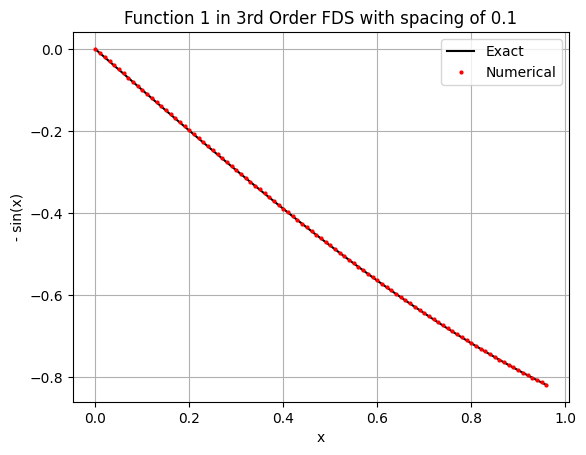

L∞ norm = 0.0008214310582399519
L2 norm = 0.00646683390374448
Root Mean square =  0.000656607500472303


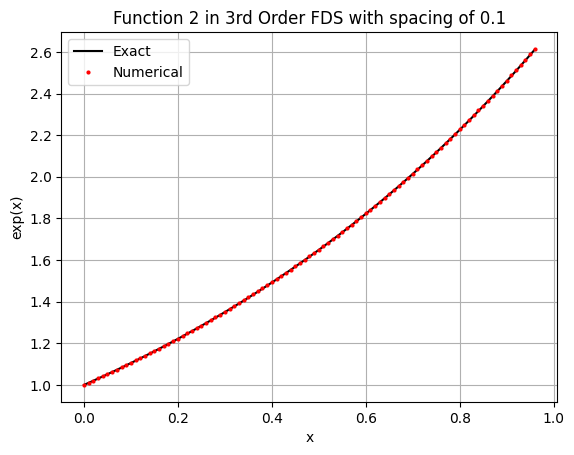

L∞ norm = 0.0025551138466819445
L2 norm = 0.01680254555407712
Root Mean square =  0.0017060400192815143


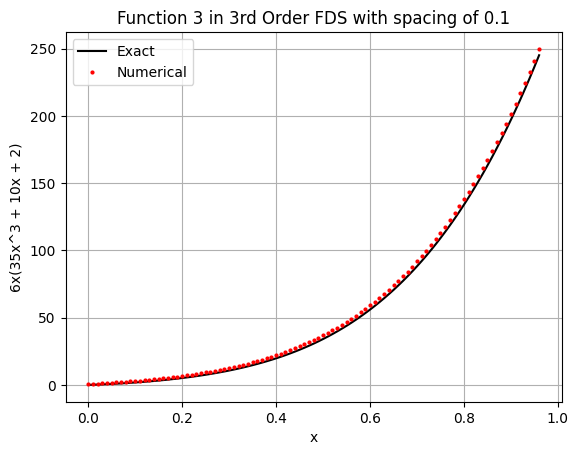

L∞ norm = 4.698399999982712
L2 norm = 28.84596746028956
Root Mean square =  2.9288642440374164


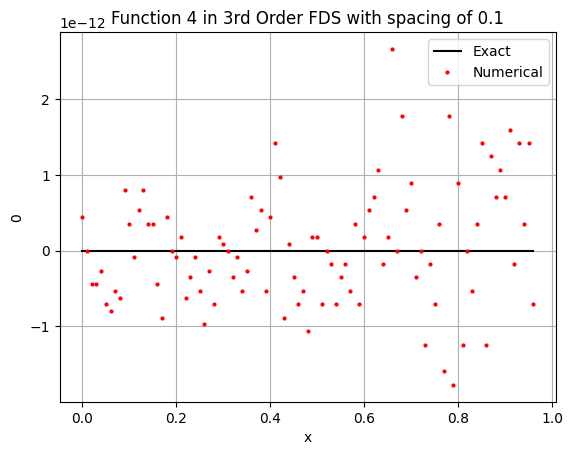

L∞ norm = 2.6645352591003753e-12
L2 norm = 7.724088959991664e-12
Root Mean square =  7.84262410467846e-13
 
 Error calculation for function 1 in spacing 0.01 (3rd Order FDS)
L∞ norm = 8.332139145306172e-07
L2 norm = 2.2290317602508283e-05
Root Mean square =  7.059414414645323e-07
 
 Error calculation for function 2 in spacing 0.01 (3rd Order FDS)
L∞ norm = 2.2923551905584816e-06
L2 norm = 4.7664657613388375e-05
Root Mean square =  1.5095548525841728e-06
 
 Error calculation for function 3 in spacing 0.01 (3rd Order FDS)
L∞ norm = 0.004249840197303456
L2 norm = 0.0781078366766517
Root Mean square =  0.002473700007172039

 Error calculation for function 4 in spacing 0.01 (3rd Order FDS)
L∞ norm = 3.552713678800501e-10
L2 norm = 3.1435650772865706e-09
Root Mean square =  9.955770489997535e-11
 
 Error calculation for function 1 in spacing 0.001 (3rd Order FDS)
L∞ norm = 3.0355539193394065e-09
L2 norm = 9.089635218764186e-08
Root Mean square =  9.090998970898904e-10
 
 Error calculation fo

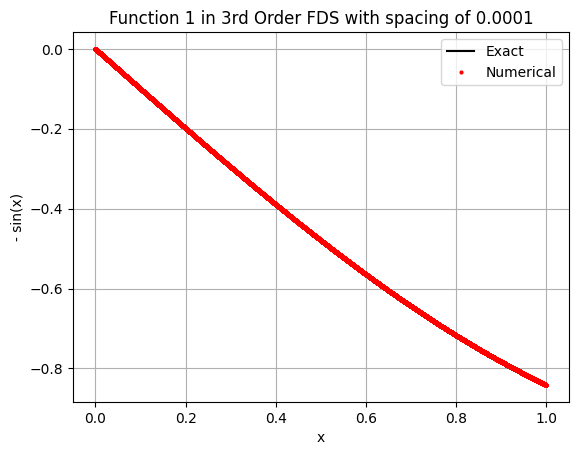

L∞ norm = 2.652937051150772e-07
L2 norm = 1.6021414273247866e-05
Root Mean square =  5.0664920420100726e-08


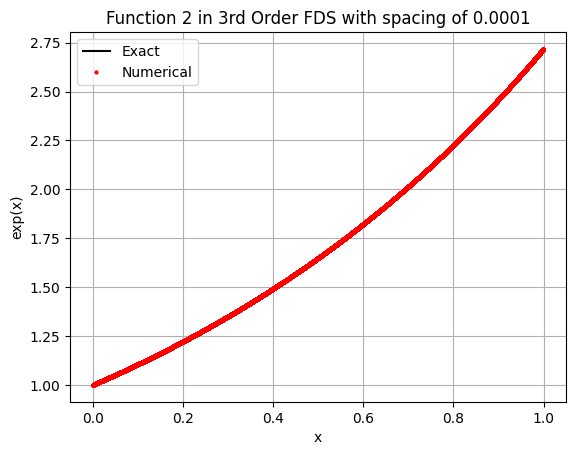

L∞ norm = 8.806384994564098e-07
L2 norm = 5.758056710223686e-05
Root Mean square =  1.8208847235480053e-07


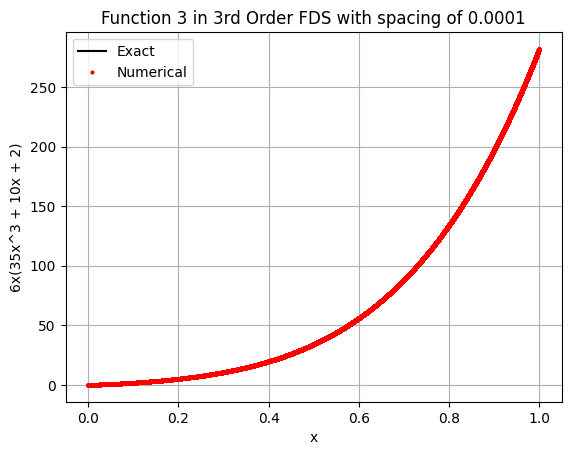

L∞ norm = 9.863130827625355e-06
L2 norm = 0.00036429970002332447
Root Mean square =  1.1520340836306614e-06


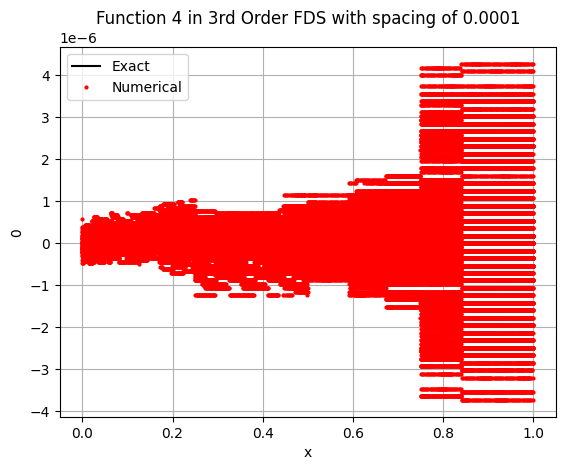

L∞ norm = 4.263256414560601e-06
L2 norm = 0.00031032241101104
Root Mean square =  9.813403480054243e-07


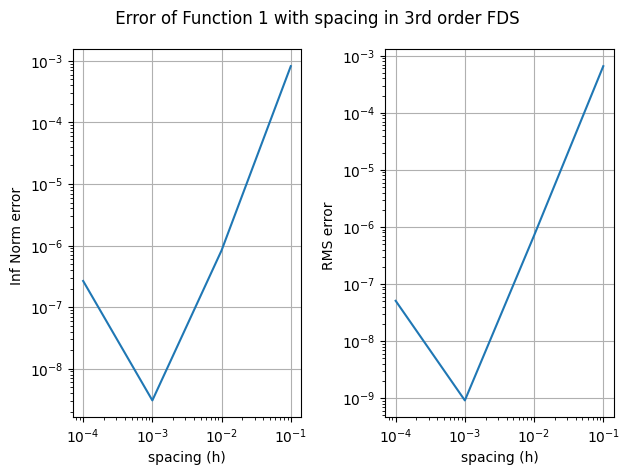

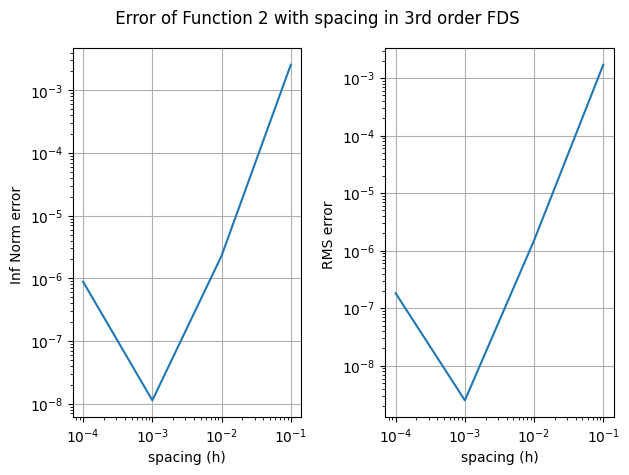

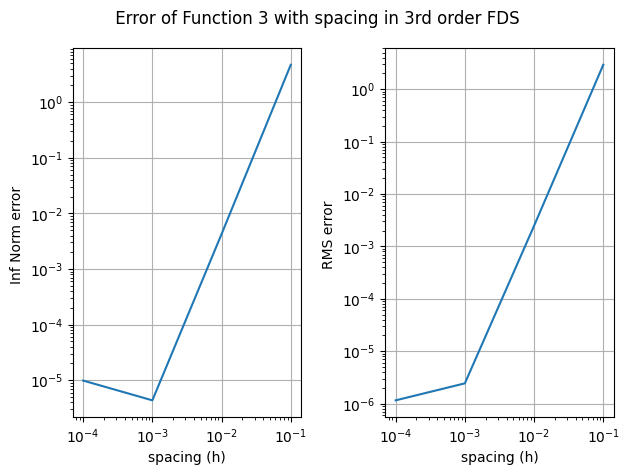

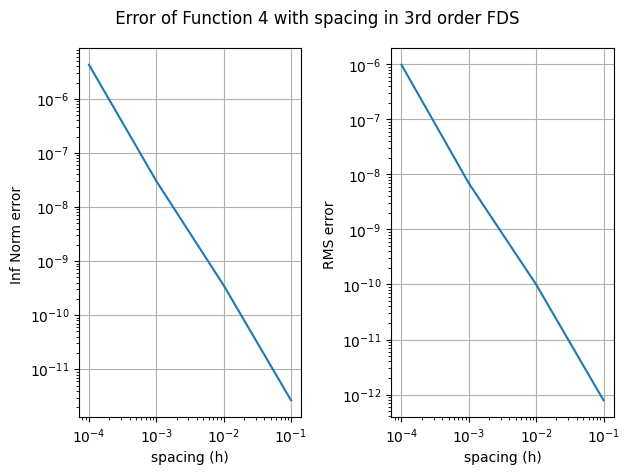

In [28]:
## Visualization

#### ------------------   case b1: 3rd order FDS & spacing is 0.1 ----------#
dx = 0.1 #delta_xs(i)
N = int(10/dx) + 1
xs = np.linspace(0,1,N)

plt.plot(xs[:-4], d2f_dx2_1_exact_array_b1[:-4], 'k-', label="Exact")
plt.plot(xs[:-4], d2f_dx2_1_num_b1[:-4], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('- sin(x)')
plt.title('Function 1 in 3rd Order FDS with spacing of 0.1')
plt.grid(True)
plt.show()

# error of funcn 1

Linf_f1_b1 = np.max(np.abs(d2f_dx2_1_err_b1[:-4])) # Linf norm
L2_f1_b1 = np.sqrt(np.sum((d2f_dx2_1_err_b1[:-4])**2)) # L2 norm
RMSE_f1_b1 = np.sqrt(np.mean((d2f_dx2_1_err_b1[:-4])**2))
print("L∞ norm =", Linf_f1_b1)
print("L2 norm =", L2_f1_b1)
print("Root Mean square = ", RMSE_f1_b1)

plt.plot(xs[:-4], d2f_dx2_2_exact_array_b1[:-4], 'k-', label="Exact")
plt.plot(xs[:-4], d2f_dx2_2_num_b1[:-4], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('exp(x)')
plt.title('Function 2 in 3rd Order FDS with spacing of 0.1')
plt.grid(True)
plt.show()

Linf_f2_b1 = np.max(np.abs(d2f_dx2_2_err_b1[:-4])) # Linf norm
L2_f2_b1 = np.sqrt(np.sum((d2f_dx2_2_err_b1[:-4])**2)) # L2 norm
RMSE_f2_b1 = np.sqrt(np.mean((d2f_dx2_2_err_b1[:-4])**2))
print("L∞ norm =", Linf_f2_b1)
print("L2 norm =", L2_f2_b1)
print("Root Mean square = ", RMSE_f2_b1)

plt.plot(xs[:-4], d2f_dx2_3_exact_array_b1[:-4], 'k-', label="Exact")
plt.plot(xs[:-4], d2f_dx2_3_num_b1[:-4], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('6x(35x^3 + 10x + 2)')
plt.title('Function 3 in 3rd Order FDS with spacing of 0.1')
plt.grid(True)
plt.show()

Linf_f3_b1 = np.max(np.abs(d2f_dx2_3_err_b1[:-4])) # Linf norm
L2_f3_b1 = np.sqrt(np.sum((d2f_dx2_3_err_b1[:-4])**2)) # L2 norm
RMSE_f3_b1 = np.sqrt(np.mean((d2f_dx2_3_err_b1[:-4])**2))
print("L∞ norm =", Linf_f3_b1)
print("L2 norm =", L2_f3_b1)
print("Root Mean square = ", RMSE_f3_b1)

plt.plot(xs[:-4], d2f_dx2_4_exact_array_b1[:-4], 'k-', label="Exact")
plt.plot(xs[:-4], d2f_dx2_4_num_b1[:-4], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('0')
plt.title('Function 4 in 3rd Order FDS with spacing of 0.1')
plt.grid(True)
plt.show()

Linf_f4_b1 = np.max(np.abs(d2f_dx2_4_err_b1[:-4])) # Linf norm
L2_f4_b1 = np.sqrt(np.sum((d2f_dx2_4_err_b1[:-4])**2)) # L2 norm
RMSE_f4_b1 = np.sqrt(np.mean((d2f_dx2_4_err_b1[:-4])**2))
print("L∞ norm =", Linf_f4_b1)
print("L2 norm =", L2_f4_b1)
print("Root Mean square = ", RMSE_f4_b1)

#### ------------------   case b2: 3rd order FDS & spacing is 0.01 ----------#

Linf_f1_b2 = np.max(np.abs(d2f_dx2_1_err_b2[:-4]))
L2_f1_b2 = np.sqrt(np.sum((d2f_dx2_1_err_b2[:-4])**2))
RMSE_f1_b2 = np.sqrt(np.mean((d2f_dx2_1_err_b2[:-4])**2))
print(" \n Error calculation for function 1 in spacing 0.01 (3rd Order FDS)")
print("L∞ norm =", Linf_f1_b2)
print("L2 norm =", L2_f1_b2)
print("Root Mean square = ", RMSE_f1_b2)

Linf_f2_b2 = np.max(np.abs(d2f_dx2_2_err_b2[:-4]))
L2_f2_b2 = np.sqrt(np.sum((d2f_dx2_2_err_b2[:-4])**2))
RMSE_f2_b2 = np.sqrt(np.mean((d2f_dx2_2_err_b2[:-4])**2))
print(" \n Error calculation for function 2 in spacing 0.01 (3rd Order FDS)")
print("L∞ norm =", Linf_f2_b2)
print("L2 norm =", L2_f2_b2)
print("Root Mean square = ", RMSE_f2_b2)

Linf_f3_b2 = np.max(np.abs(d2f_dx2_3_err_b2[:-4]))
L2_f3_b2 = np.sqrt(np.sum((d2f_dx2_3_err_b2[:-4])**2))
RMSE_f3_b2 = np.sqrt(np.mean((d2f_dx2_3_err_b2[:-4])**2))
print(" \n Error calculation for function 3 in spacing 0.01 (3rd Order FDS)")
print("L∞ norm =", Linf_f3_b2)
print("L2 norm =", L2_f3_b2)
print("Root Mean square = ", RMSE_f3_b2)

Linf_f4_b2 = np.max(np.abs(d2f_dx2_4_err_b2[:-4]))
L2_f4_b2 = np.sqrt(np.sum((d2f_dx2_4_err_b2[:-4])**2))
RMSE_f4_b2 = np.sqrt(np.mean((d2f_dx2_4_err_b2[:-4])**2))
print("\n Error calculation for function 4 in spacing 0.01 (3rd Order FDS)")
print("L∞ norm =", Linf_f4_b2)
print("L2 norm =", L2_f4_b2)
print("Root Mean square = ", RMSE_f4_b2)

#### ------------------   case b3: 3rd order FDS & spacing is 0.001 ----------#

Linf_f1_b3 = np.max(np.abs(d2f_dx2_1_err_b3[:-4]))
L2_f1_b3 = np.sqrt(np.sum((d2f_dx2_1_err_b3[:-4])**2))
RMSE_f1_b3 = np.sqrt(np.mean((d2f_dx2_1_err_b3[:-4])**2))
print(" \n Error calculation for function 1 in spacing 0.001 (3rd Order FDS)")
print("L∞ norm =", Linf_f1_b3)
print("L2 norm =", L2_f1_b3)
print("Root Mean square = ", RMSE_f1_b3)

Linf_f2_b3 = np.max(np.abs(d2f_dx2_2_err_b3[:-4]))
L2_f2_b3 = np.sqrt(np.sum((d2f_dx2_2_err_b3[:-4])**2))
RMSE_f2_b3 = np.sqrt(np.mean((d2f_dx2_2_err_b3[:-4])**2))
print(" \n Error calculation for function 2 in spacing 0.001 (3rd Order FDS)")
print("L∞ norm =", Linf_f2_b3)
print("L2 norm =", L2_f2_b3)
print("Root Mean square = ", RMSE_f2_b3)

Linf_f3_b3 = np.max(np.abs(d2f_dx2_3_err_b3[:-4]))
L2_f3_b3 = np.sqrt(np.sum((d2f_dx2_3_err_b3[:-4])**2))
RMSE_f3_b3 = np.sqrt(np.mean((d2f_dx2_3_err_b3[:-4])**2))
print(" \n Error calculation for function 3 in spacing 0.001 (3rd Order FDS)")
print("L∞ norm =", Linf_f3_b3)
print("L2 norm =", L2_f3_b3)
print("Root Mean square = ", RMSE_f3_b3)

Linf_f4_b3 = np.max(np.abs(d2f_dx2_4_err_b3[:-4]))
L2_f4_b3 = np.sqrt(np.sum((d2f_dx2_4_err_b3[:-4])**2))
RMSE_f4_b3 = np.sqrt(np.mean((d2f_dx2_4_err_b3[:-4])**2))
print("\n Error calculation for function 4 in spacing 0.001 (3rd Order FDS)")
print("L∞ norm =", Linf_f4_b3)
print("L2 norm =", L2_f4_b3)
print("Root Mean square = ", RMSE_f4_b3)

#### ------------------   case b4: 3rd order FDS & spacing is 0.0001 ----------#
dx = 0.0001
N = int(10/dx) + 1
xs = np.linspace(0,1,N)

plt.plot(xs[:-4], d2f_dx2_1_exact_array_b4[:-4], 'k-', label="Exact")
plt.plot(xs[:-4], d2f_dx2_1_num_b4[:-4], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('- sin(x)')
plt.title('Function 1 in 3rd Order FDS with spacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f1_b4 = np.max(np.abs(d2f_dx2_1_err_b4[:-4]))
L2_f1_b4 = np.sqrt(np.sum((d2f_dx2_1_err_b4[:-4])**2))
RMSE_f1_b4 = np.sqrt(np.mean((d2f_dx2_1_err_b4[:-4])**2))
print("L∞ norm =", Linf_f1_b4)
print("L2 norm =", L2_f1_b4)
print("Root Mean square = ", RMSE_f1_b4)

plt.plot(xs[:-4], d2f_dx2_2_exact_array_b4[:-4], 'k-', label="Exact")
plt.plot(xs[:-4], d2f_dx2_2_num_b4[:-4], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('exp(x)')
plt.title('Function 2 in 3rd Order FDS with spacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f2_b4 = np.max(np.abs(d2f_dx2_2_err_b4[:-4]))
L2_f2_b4 = np.sqrt(np.sum((d2f_dx2_2_err_b4[:-4])**2))
RMSE_f2_b4 = np.sqrt(np.mean((d2f_dx2_2_err_b4[:-4])**2))
print("L∞ norm =", Linf_f2_b4)
print("L2 norm =", L2_f2_b4)
print("Root Mean square = ", RMSE_f2_b4)

plt.plot(xs[:-4], d2f_dx2_3_exact_array_b4[:-4], 'k-', label="Exact")
plt.plot(xs[:-4], d2f_dx2_3_num_b4[:-4], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('6x(35x^3 + 10x + 2)')
plt.title('Function 3 in 3rd Order FDS with spacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f3_b4 = np.max(np.abs(d2f_dx2_3_err_b4[:-4]))
L2_f3_b4 = np.sqrt(np.sum((d2f_dx2_3_err_b4[:-4])**2))
RMSE_f3_b4 = np.sqrt(np.mean((d2f_dx2_3_err_b4[:-4])**2))
print("L∞ norm =", Linf_f3_b4)
print("L2 norm =", L2_f3_b4)
print("Root Mean square = ", RMSE_f3_b4)

plt.plot(xs[:-4], d2f_dx2_4_exact_array_b4[:-4], 'k-', label="Exact")
plt.plot(xs[:-4], d2f_dx2_4_num_b4[:-4], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('0')
plt.title('Function 4 in 3rd Order FDS with spacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f4_b4 = np.max(np.abs(d2f_dx2_4_err_b4[:-4]))
L2_f4_b4 = np.sqrt(np.sum((d2f_dx2_4_err_b4[:-4])**2))
RMSE_f4_b4 = np.sqrt(np.mean((d2f_dx2_4_err_b4[:-4])**2))
print("L∞ norm =", Linf_f4_b4)
print("L2 norm =", L2_f4_b4)
print("Root Mean square = ", RMSE_f4_b4)

## Histogram/Log-Log plots for the 3rd order FDS scheme
Linf_hist_f1_b = [Linf_f1_b1, Linf_f1_b2, Linf_f1_b3, Linf_f1_b4]
Linf_hist_f2_b = [Linf_f2_b1, Linf_f2_b2, Linf_f2_b3, Linf_f2_b4]
Linf_hist_f3_b = [Linf_f3_b1, Linf_f3_b2, Linf_f3_b3, Linf_f3_b4]
Linf_hist_f4_b = [Linf_f4_b1, Linf_f4_b2, Linf_f4_b3, Linf_f4_b4]

RMSE_hist_f1_b = [RMSE_f1_b1, RMSE_f1_b2, RMSE_f1_b3, RMSE_f1_b4]
RMSE_hist_f2_b = [RMSE_f2_b1, RMSE_f2_b2, RMSE_f2_b3, RMSE_f2_b4]
RMSE_hist_f3_b = [RMSE_f3_b1, RMSE_f3_b2, RMSE_f3_b3, RMSE_f3_b4]
RMSE_hist_f4_b = [RMSE_f4_b1, RMSE_f4_b2, RMSE_f4_b3, RMSE_f4_b4]

# Final Error Plot for Function 1
plt.subplot(1,2,1)
plt.loglog(delta_xs, Linf_hist_f1_b)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs, RMSE_hist_f1_b)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")

plt.suptitle(" Error of Function 1 with spacing in 3rd order FDS" )
plt.tight_layout()
plt.grid(True)
plt.show()



# Final Error Plot for Function 2
plt.subplot(1,2,1)
plt.loglog(delta_xs, Linf_hist_f2_b)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs, RMSE_hist_f2_b)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")

plt.suptitle(" Error of Function 2 with spacing in 3rd order FDS" )
plt.tight_layout()
plt.grid(True)
plt.show()

# Final Error Plot for Function 3
plt.subplot(1,2,1)
plt.loglog(delta_xs, Linf_hist_f3_b)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs, RMSE_hist_f3_b)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")

plt.suptitle(" Error of Function 3 with spacing in 3rd order FDS" )
plt.tight_layout()
plt.grid(True)
plt.show()

# Final Error Plot for Function 4
plt.subplot(1,2,1)
plt.loglog(delta_xs, Linf_hist_f4_b)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs, RMSE_hist_f4_b)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")

plt.suptitle(" Error of Function 4 with spacing in 3rd order FDS" )
plt.tight_layout()
plt.grid(True)
plt.show()

### This is for the 4th order Central Difference scheme with 4 different functions and different types of spacing

In [29]:
####### ------    spacing is '0.1' means case 'c1' ------    ###########

dx = 0.1 #delta_xs(i)
N = int(10/dx) + 1
xs = np.linspace(0,1,N)

# for the First function (sinx)
d2f_dx2_1_exact_array_c1 = np.zeros_like(xs)
d2f_dx2_1_num_c1 = np.zeros_like(xs)
d2f_dx2_1_err_c1 = np.zeros_like(xs)
# for the 2nd function (ex)
d2f_dx2_2_exact_array_c1 = np.zeros_like(xs)
d2f_dx2_2_num_c1 = np.zeros_like(xs)
d2f_dx2_2_err_c1 = np.zeros_like(xs)
# for 3rd fucntion
d2f_dx2_3_exact_array_c1 = np.zeros_like(xs)
d2f_dx2_3_num_c1 = np.zeros_like(xs)
d2f_dx2_3_err_c1 = np.zeros_like(xs)
# For 4th function
d2f_dx2_4_exact_array_c1 = np.zeros_like(xs)
d2f_dx2_4_num_c1 = np.zeros_like(xs)
d2f_dx2_4_err_c1 = np.zeros_like(xs)

# For 4th order CDS: range starts at 2 and ends at len-2 to accommodate stencil
for i in range(2, len(xs)-2):

    # for the First function (sinx)
    exact_val = d2f_func1(xs[i])
    d2f_dx2_1_exact_array_c1[i] = exact_val
    d2f_dx2_1_num_c1[i] = central_4th(func1, xs[i], dx)
    d2f_dx2_1_err_c1[i] = d2f_dx2_1_num_c1[i] - exact_val

    # for the 2nd function (ex)
    exact_val = d2f_func2(xs[i])
    d2f_dx2_2_exact_array_c1[i] = exact_val
    d2f_dx2_2_num_c1[i] = central_4th(func2, xs[i], dx)
    d2f_dx2_2_err_c1[i] = d2f_dx2_2_num_c1[i] - exact_val

    # for 3rd function
    exact_val = d2f_func3(xs[i])
    d2f_dx2_3_exact_array_c1[i] = exact_val
    d2f_dx2_3_num_c1[i] = central_4th(func3, xs[i], dx)
    d2f_dx2_3_err_c1[i] = d2f_dx2_3_num_c1[i] - exact_val

    # For 4th function
    exact_val = d2f_func4(xs[i])
    d2f_dx2_4_exact_array_c1[i] = exact_val
    d2f_dx2_4_num_c1[i] = central_4th(func4, xs[i], dx)
    d2f_dx2_4_err_c1[i] = d2f_dx2_4_num_c1[i] - exact_val


##----------      spacing is '0.01' means case 'c2'  --------- ####

dx = 0.01
N = int(10/dx) + 1
xs = np.linspace(0,1,N)

d2f_dx2_1_exact_array_c2 = np.zeros_like(xs)
d2f_dx2_1_num_c2 = np.zeros_like(xs)
d2f_dx2_1_err_c2 = np.zeros_like(xs)
d2f_dx2_2_exact_array_c2 = np.zeros_like(xs)
d2f_dx2_2_num_c2 = np.zeros_like(xs)
d2f_dx2_2_err_c2 = np.zeros_like(xs)
d2f_dx2_3_exact_array_c2 = np.zeros_like(xs)
d2f_dx2_3_num_c2 = np.zeros_like(xs)
d2f_dx2_3_err_c2 = np.zeros_like(xs)
d2f_dx2_4_exact_array_c2 = np.zeros_like(xs)
d2f_dx2_4_num_c2 = np.zeros_like(xs)
d2f_dx2_4_err_c2 = np.zeros_like(xs)

for i in range(2, len(xs)-2):
    d2f_dx2_1_exact_array_c2[i] = d2f_func1(xs[i])
    d2f_dx2_1_num_c2[i] = central_4th(func1, xs[i], dx)
    d2f_dx2_1_err_c2[i] = d2f_dx2_1_num_c2[i] - d2f_dx2_1_exact_array_c2[i]

    d2f_dx2_2_exact_array_c2[i] = d2f_func2(xs[i])
    d2f_dx2_2_num_c2[i] = central_4th(func2, xs[i], dx)
    d2f_dx2_2_err_c2[i] = d2f_dx2_2_num_c2[i] - d2f_dx2_2_exact_array_c2[i]

    d2f_dx2_3_exact_array_c2[i] = d2f_func3(xs[i])
    d2f_dx2_3_num_c2[i] = central_4th(func3, xs[i], dx)
    d2f_dx2_3_err_c2[i] = d2f_dx2_3_num_c2[i] - d2f_dx2_3_exact_array_c2[i]

    d2f_dx2_4_exact_array_c2[i] = d2f_func4(xs[i])
    d2f_dx2_4_num_c2[i] = central_4th(func4, xs[i], dx)
    d2f_dx2_4_err_c2[i] = d2f_dx2_4_num_c2[i] - d2f_dx2_4_exact_array_c2[i]


##----------      spacing is '0.001' means case 'c3'  --------- ####

dx = 0.001
N = int(10/dx) + 1
xs = np.linspace(0,1,N)

d2f_dx2_1_exact_array_c3 = np.zeros_like(xs)
d2f_dx2_1_num_c3 = np.zeros_like(xs)
d2f_dx2_1_err_c3 = np.zeros_like(xs)
d2f_dx2_2_exact_array_c3 = np.zeros_like(xs)
d2f_dx2_2_num_c3 = np.zeros_like(xs)
d2f_dx2_2_err_c3 = np.zeros_like(xs)
d2f_dx2_3_exact_array_c3 = np.zeros_like(xs)
d2f_dx2_3_num_c3 = np.zeros_like(xs)
d2f_dx2_3_err_c3 = np.zeros_like(xs)
d2f_dx2_4_exact_array_c3 = np.zeros_like(xs)
d2f_dx2_4_num_c3 = np.zeros_like(xs)
d2f_dx2_4_err_c3 = np.zeros_like(xs)

for i in range(2, len(xs)-2):
    d2f_dx2_1_exact_array_c3[i] = d2f_func1(xs[i])
    d2f_dx2_1_num_c3[i] = central_4th(func1, xs[i], dx)
    d2f_dx2_1_err_c3[i] = d2f_dx2_1_num_c3[i] - d2f_dx2_1_exact_array_c3[i]

    d2f_dx2_2_exact_array_c3[i] = d2f_func2(xs[i])
    d2f_dx2_2_num_c3[i] = central_4th(func2, xs[i], dx)
    d2f_dx2_2_err_c3[i] = d2f_dx2_2_num_c3[i] - d2f_dx2_2_exact_array_c3[i]

    d2f_dx2_3_exact_array_c3[i] = d2f_func3(xs[i])
    d2f_dx2_3_num_c3[i] = central_4th(func3, xs[i], dx)
    d2f_dx2_3_err_c3[i] = d2f_dx2_3_num_c3[i] - d2f_dx2_3_exact_array_c3[i]

    d2f_dx2_4_exact_array_c3[i] = d2f_func4(xs[i])
    d2f_dx2_4_num_c3[i] = central_4th(func4, xs[i], dx)
    d2f_dx2_4_err_c3[i] = d2f_dx2_4_num_c3[i] - d2f_dx2_4_exact_array_c3[i]


##----------      spacing is '0.0001' means case 'c4'  --------- ####

dx = 0.0001
N = int(10/dx) + 1
xs = np.linspace(0,1,N)

d2f_dx2_1_exact_array_c4 = np.zeros_like(xs)
d2f_dx2_1_num_c4 = np.zeros_like(xs)
d2f_dx2_1_err_c4 = np.zeros_like(xs)
d2f_dx2_2_exact_array_c4 = np.zeros_like(xs)
d2f_dx2_2_num_c4 = np.zeros_like(xs)
d2f_dx2_2_err_c4 = np.zeros_like(xs)
d2f_dx2_3_exact_array_c4 = np.zeros_like(xs)
d2f_dx2_3_num_c4 = np.zeros_like(xs)
d2f_dx2_3_err_c4 = np.zeros_like(xs)
d2f_dx2_4_exact_array_c4 = np.zeros_like(xs)
d2f_dx2_4_num_c4 = np.zeros_like(xs)
d2f_dx2_4_err_c4 = np.zeros_like(xs)

for i in range(2, len(xs)-2):
    d2f_dx2_1_exact_array_c4[i] = d2f_func1(xs[i])
    d2f_dx2_1_num_c4[i] = central_4th(func1, xs[i], dx)
    d2f_dx2_1_err_c4[i] = d2f_dx2_1_num_c4[i] - d2f_dx2_1_exact_array_c4[i]

    d2f_dx2_2_exact_array_c4[i] = d2f_func2(xs[i])
    d2f_dx2_2_num_c4[i] = central_4th(func2, xs[i], dx)
    d2f_dx2_2_err_c4[i] = d2f_dx2_2_num_c4[i] - d2f_dx2_2_exact_array_c4[i]

    d2f_dx2_3_exact_array_c4[i] = d2f_func3(xs[i])
    d2f_dx2_3_num_c4[i] = central_4th(func3, xs[i], dx)
    d2f_dx2_3_err_c4[i] = d2f_dx2_3_num_c4[i] - d2f_dx2_3_exact_array_c4[i]

    d2f_dx2_4_exact_array_c4[i] = d2f_func4(xs[i])
    d2f_dx2_4_num_c4[i] = central_4th(func4, xs[i], dx)
    d2f_dx2_4_err_c4[i] = d2f_dx2_4_num_c4[i] - d2f_dx2_4_exact_array_c4[i]

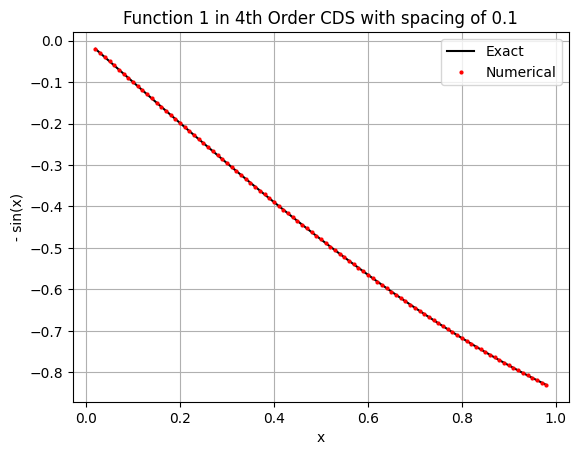

L∞ norm = 9.219513447122907e-07
L2 norm = 5.683903605017856e-06
Root Mean square =  5.771129728344033e-07


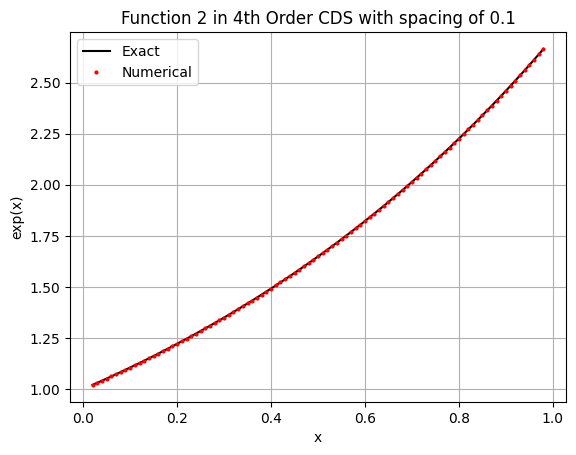

L∞ norm = 2.963151427781696e-06
L2 norm = 1.9485819696618352e-05
Root Mean square =  1.9784852303446583e-06


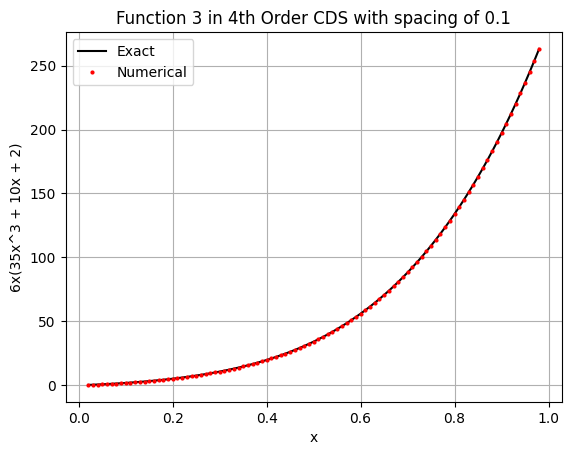

L∞ norm = 0.005600000001237504
L2 norm = 0.0551536036902161
Root Mean square =  0.005600000000016034


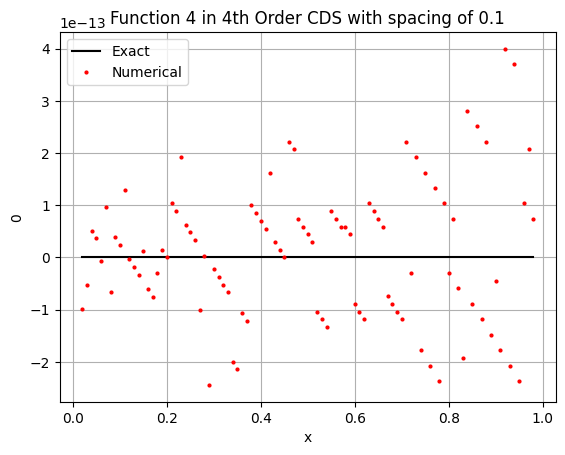

L∞ norm = 3.9968028886505625e-13
L2 norm = 1.2958468946909177e-12
Root Mean square =  1.315733175124732e-13
 
 Error calculation for function 1 in spacing 0.01 (4th Order CDS)
L∞ norm = 9.501543996037753e-11
L2 norm = 1.8306800414344142e-09
Root Mean square =  5.7978218630906106e-11
 
 Error calculation for function 2 in spacing 0.01 (4th Order CDS)
L∞ norm = 3.099724921185043e-10
L2 norm = 6.272010005345537e-09
Root Mean square =  1.9863654986931907e-10
 
 Error calculation for function 3 in spacing 0.01 (4th Order CDS)
L∞ norm = 5.601964971901907e-07
L2 norm = 1.7682197455258423e-05
Root Mean square =  5.6000081212037e-07

 Error calculation for function 4 in spacing 0.01 (4th Order CDS)
L∞ norm = 7.993605777301126e-11
L2 norm = 5.760824973266539e-10
Root Mean square =  1.8244715746872207e-11
 
 Error calculation for function 1 in spacing 0.001 (4th Order CDS)
L∞ norm = 4.44908554442236e-10
L2 norm = 1.036252700900563e-08
Root Mean square =  1.0364081737879724e-10
 
 Error calculatio

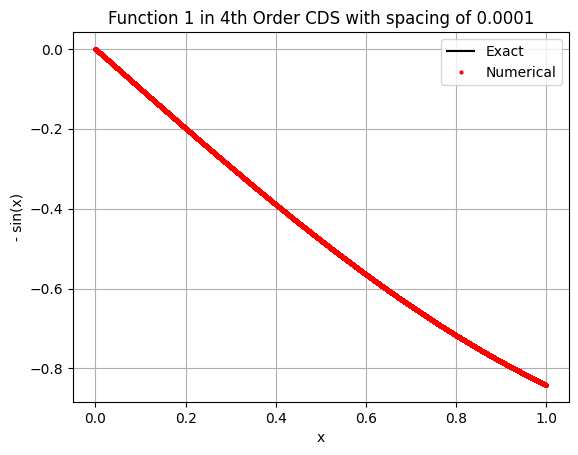

L∞ norm = 4.60508430277784e-08
L2 norm = 3.2150326617987325e-06
Root Mean square =  1.0166978468938649e-08


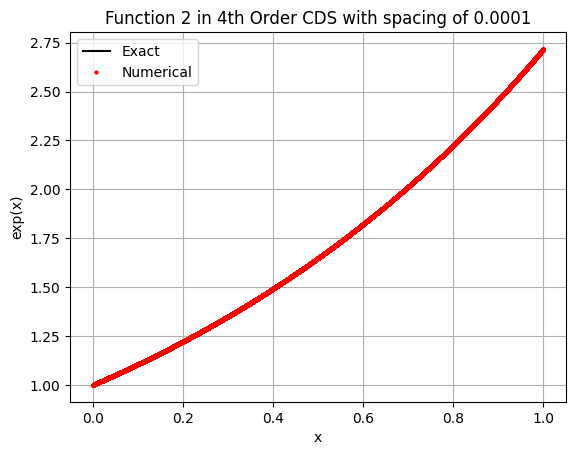

L∞ norm = 1.889926752873805e-07
L2 norm = 1.1846220508489904e-05
Root Mean square =  3.746160039964661e-08


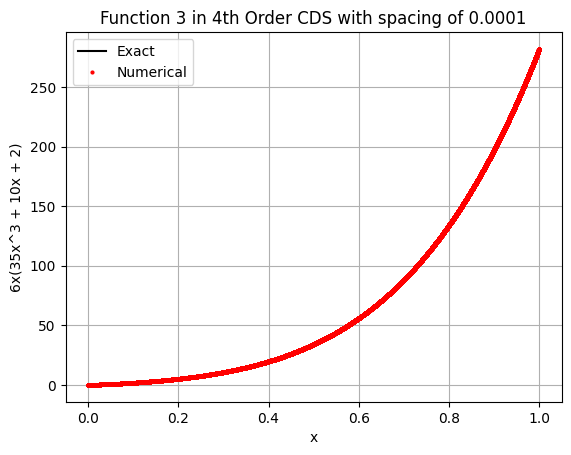

L∞ norm = 1.9697431810072885e-06
L2 norm = 7.681249635048706e-05
Root Mean square =  2.429060848495105e-07


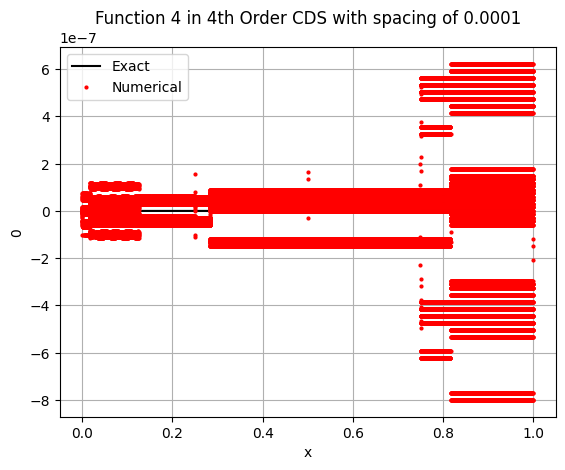

L∞ norm = 7.993605777301126e-07
L2 norm = 5.9447221644664565e-05
Root Mean square =  1.8799144085876312e-07


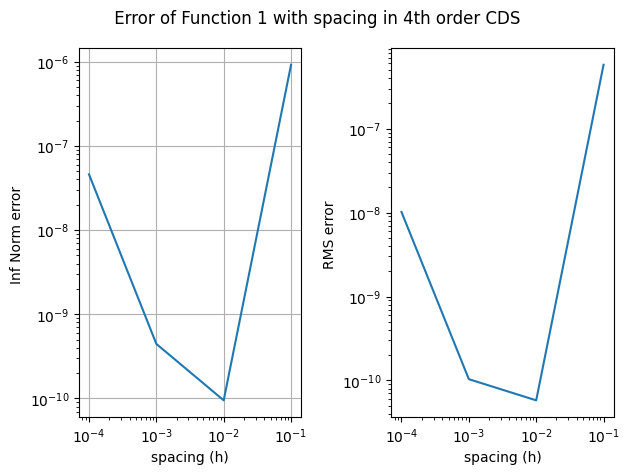

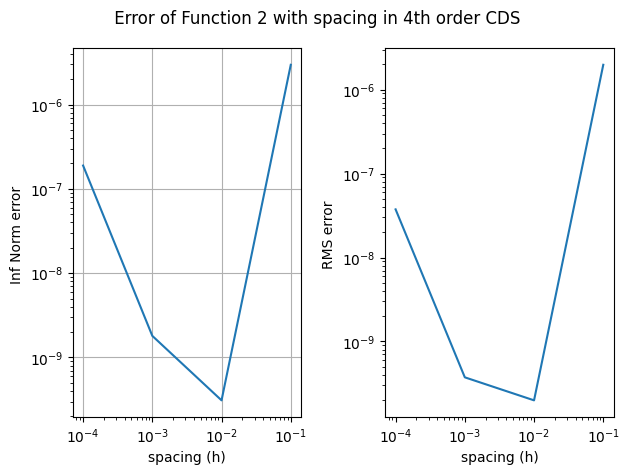

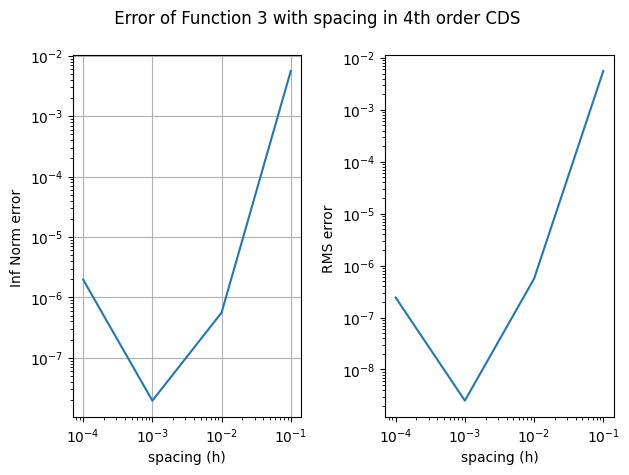

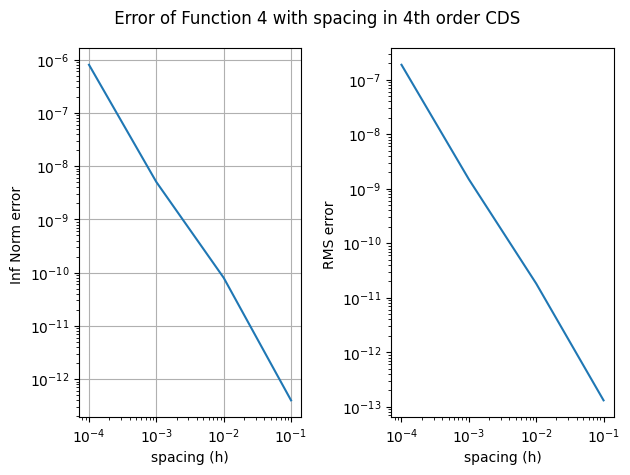

In [30]:
## Visualization

#### ------------------   case c1: 4th order CDS & spacing is 0.1 ----------#
dx = 0.1 #delta_xs(i)
N = int(10/dx) + 1
xs = np.linspace(0,1,N)

plt.plot(xs[2:-2], d2f_dx2_1_exact_array_c1[2:-2], 'k-', label="Exact")
plt.plot(xs[2:-2], d2f_dx2_1_num_c1[2:-2], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('- sin(x)')
plt.title('Function 1 in 4th Order CDS with spacing of 0.1')
plt.grid(True)
plt.show()

# error of funcn 1

Linf_f1_c1 = np.max(np.abs(d2f_dx2_1_err_c1[2:-2])) # Linf norm
L2_f1_c1 = np.sqrt(np.sum((d2f_dx2_1_err_c1[2:-2])**2)) # L2 norm
RMSE_f1_c1 = np.sqrt(np.mean((d2f_dx2_1_err_c1[2:-2])**2))
print("L∞ norm =", Linf_f1_c1)
print("L2 norm =", L2_f1_c1)
print("Root Mean square = ", RMSE_f1_c1)

plt.plot(xs[2:-2], d2f_dx2_2_exact_array_c1[2:-2], 'k-', label="Exact")
plt.plot(xs[2:-2], d2f_dx2_2_num_c1[2:-2], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('exp(x)')
plt.title('Function 2 in 4th Order CDS with spacing of 0.1')
plt.grid(True)
plt.show()

Linf_f2_c1 = np.max(np.abs(d2f_dx2_2_err_c1[2:-2])) # Linf norm
L2_f2_c1 = np.sqrt(np.sum((d2f_dx2_2_err_c1[2:-2])**2)) # L2 norm
RMSE_f2_c1 = np.sqrt(np.mean((d2f_dx2_2_err_c1[2:-2])**2))
print("L∞ norm =", Linf_f2_c1)
print("L2 norm =", L2_f2_c1)
print("Root Mean square = ", RMSE_f2_c1)

plt.plot(xs[2:-2], d2f_dx2_3_exact_array_c1[2:-2], 'k-', label="Exact")
plt.plot(xs[2:-2], d2f_dx2_3_num_c1[2:-2], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('6x(35x^3 + 10x + 2)')
plt.title('Function 3 in 4th Order CDS with spacing of 0.1')
plt.grid(True)
plt.show()

Linf_f3_c1 = np.max(np.abs(d2f_dx2_3_err_c1[2:-2])) # Linf norm
L2_f3_c1 = np.sqrt(np.sum((d2f_dx2_3_err_c1[2:-2])**2)) # L2 norm
RMSE_f3_c1 = np.sqrt(np.mean((d2f_dx2_3_err_c1[2:-2])**2))
print("L∞ norm =", Linf_f3_c1)
print("L2 norm =", L2_f3_c1)
print("Root Mean square = ", RMSE_f3_c1)

plt.plot(xs[2:-2], d2f_dx2_4_exact_array_c1[2:-2], 'k-', label="Exact")
plt.plot(xs[2:-2], d2f_dx2_4_num_c1[2:-2], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('0')
plt.title('Function 4 in 4th Order CDS with spacing of 0.1')
plt.grid(True)
plt.show()

Linf_f4_c1 = np.max(np.abs(d2f_dx2_4_err_c1[2:-2])) # Linf norm
L2_f4_c1 = np.sqrt(np.sum((d2f_dx2_4_err_c1[2:-2])**2)) # L2 norm
RMSE_f4_c1 = np.sqrt(np.mean((d2f_dx2_4_err_c1[2:-2])**2))
print("L∞ norm =", Linf_f4_c1)
print("L2 norm =", L2_f4_c1)
print("Root Mean square = ", RMSE_f4_c1)

#### ------------------   case c2: 4th order CDS & spacing is 0.01 ----------#

Linf_f1_c2 = np.max(np.abs(d2f_dx2_1_err_c2[2:-2]))
L2_f1_c2 = np.sqrt(np.sum((d2f_dx2_1_err_c2[2:-2])**2))
RMSE_f1_c2 = np.sqrt(np.mean((d2f_dx2_1_err_c2[2:-2])**2))
print(" \n Error calculation for function 1 in spacing 0.01 (4th Order CDS)")
print("L∞ norm =", Linf_f1_c2)
print("L2 norm =", L2_f1_c2)
print("Root Mean square = ", RMSE_f1_c2)

Linf_f2_c2 = np.max(np.abs(d2f_dx2_2_err_c2[2:-2]))
L2_f2_c2 = np.sqrt(np.sum((d2f_dx2_2_err_c2[2:-2])**2))
RMSE_f2_c2 = np.sqrt(np.mean((d2f_dx2_2_err_c2[2:-2])**2))
print(" \n Error calculation for function 2 in spacing 0.01 (4th Order CDS)")
print("L∞ norm =", Linf_f2_c2)
print("L2 norm =", L2_f2_c2)
print("Root Mean square = ", RMSE_f2_c2)

Linf_f3_c2 = np.max(np.abs(d2f_dx2_3_err_c2[2:-2]))
L2_f3_c2 = np.sqrt(np.sum((d2f_dx2_3_err_c2[2:-2])**2))
RMSE_f3_c2 = np.sqrt(np.mean((d2f_dx2_3_err_c2[2:-2])**2))
print(" \n Error calculation for function 3 in spacing 0.01 (4th Order CDS)")
print("L∞ norm =", Linf_f3_c2)
print("L2 norm =", L2_f3_c2)
print("Root Mean square = ", RMSE_f3_c2)

Linf_f4_c2 = np.max(np.abs(d2f_dx2_4_err_c2[2:-2]))
L2_f4_c2 = np.sqrt(np.sum((d2f_dx2_4_err_c2[2:-2])**2))
RMSE_f4_c2 = np.sqrt(np.mean((d2f_dx2_4_err_c2[2:-2])**2))
print("\n Error calculation for function 4 in spacing 0.01 (4th Order CDS)")
print("L∞ norm =", Linf_f4_c2)
print("L2 norm =", L2_f4_c2)
print("Root Mean square = ", RMSE_f4_c2)

#### ------------------   case c3: 4th order CDS & spacing is 0.001 ----------#

Linf_f1_c3 = np.max(np.abs(d2f_dx2_1_err_c3[2:-2]))
L2_f1_c3 = np.sqrt(np.sum((d2f_dx2_1_err_c3[2:-2])**2))
RMSE_f1_c3 = np.sqrt(np.mean((d2f_dx2_1_err_c3[2:-2])**2))
print(" \n Error calculation for function 1 in spacing 0.001 (4th Order CDS)")
print("L∞ norm =", Linf_f1_c3)
print("L2 norm =", L2_f1_c3)
print("Root Mean square = ", RMSE_f1_c3)

Linf_f2_c3 = np.max(np.abs(d2f_dx2_2_err_c3[2:-2]))
L2_f2_c3 = np.sqrt(np.sum((d2f_dx2_2_err_c3[2:-2])**2))
RMSE_f2_c3 = np.sqrt(np.mean((d2f_dx2_2_err_c3[2:-2])**2))
print(" \n Error calculation for function 2 in spacing 0.001 (4th Order CDS)")
print("L∞ norm =", Linf_f2_c3)
print("L2 norm =", L2_f2_c3)
print("Root Mean square = ", RMSE_f2_c3)

Linf_f3_c3 = np.max(np.abs(d2f_dx2_3_err_c3[2:-2]))
L2_f3_c3 = np.sqrt(np.sum((d2f_dx2_3_err_c3[2:-2])**2))
RMSE_f3_c3 = np.sqrt(np.mean((d2f_dx2_3_err_c3[2:-2])**2))
print(" \n Error calculation for function 3 in spacing 0.001 (4th Order CDS)")
print("L∞ norm =", Linf_f3_c3)
print("L2 norm =", L2_f3_c3)
print("Root Mean square = ", RMSE_f3_c3)

Linf_f4_c3 = np.max(np.abs(d2f_dx2_4_err_c3[2:-2]))
L2_f4_c3 = np.sqrt(np.sum((d2f_dx2_4_err_c3[2:-2])**2))
RMSE_f4_c3 = np.sqrt(np.mean((d2f_dx2_4_err_c3[2:-2])**2))
print("\n Error calculation for function 4 in spacing 0.001 (4th Order CDS)")
print("L∞ norm =", Linf_f4_c3)
print("L2 norm =", L2_f4_c3)
print("Root Mean square = ", RMSE_f4_c3)

#### ------------------   case c4: 4th order CDS & spacing is 0.0001 ----------#
dx = 0.0001
N = int(10/dx) + 1
xs = np.linspace(0,1,N)

plt.plot(xs[2:-2], d2f_dx2_1_exact_array_c4[2:-2], 'k-', label="Exact")
plt.plot(xs[2:-2], d2f_dx2_1_num_c4[2:-2], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('- sin(x)')
plt.title('Function 1 in 4th Order CDS with spacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f1_c4 = np.max(np.abs(d2f_dx2_1_err_c4[2:-2]))
L2_f1_c4 = np.sqrt(np.sum((d2f_dx2_1_err_c4[2:-2])**2))
RMSE_f1_c4 = np.sqrt(np.mean((d2f_dx2_1_err_c4[2:-2])**2))
print("L∞ norm =", Linf_f1_c4)
print("L2 norm =", L2_f1_c4)
print("Root Mean square = ", RMSE_f1_c4)

plt.plot(xs[2:-2], d2f_dx2_2_exact_array_c4[2:-2], 'k-', label="Exact")
plt.plot(xs[2:-2], d2f_dx2_2_num_c4[2:-2], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('exp(x)')
plt.title('Function 2 in 4th Order CDS with spacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f2_c4 = np.max(np.abs(d2f_dx2_2_err_c4[2:-2]))
L2_f2_c4 = np.sqrt(np.sum((d2f_dx2_2_err_c4[2:-2])**2))
RMSE_f2_c4 = np.sqrt(np.mean((d2f_dx2_2_err_c4[2:-2])**2))
print("L∞ norm =", Linf_f2_c4)
print("L2 norm =", L2_f2_c4)
print("Root Mean square = ", RMSE_f2_c4)

plt.plot(xs[2:-2], d2f_dx2_3_exact_array_c4[2:-2], 'k-', label="Exact")
plt.plot(xs[2:-2], d2f_dx2_3_num_c4[2:-2], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('6x(35x^3 + 10x + 2)')
plt.title('Function 3 in 4th Order CDS with spacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f3_c4 = np.max(np.abs(d2f_dx2_3_err_c4[2:-2]))
L2_f3_c4 = np.sqrt(np.sum((d2f_dx2_3_err_c4[2:-2])**2))
RMSE_f3_c4 = np.sqrt(np.mean((d2f_dx2_3_err_c4[2:-2])**2))
print("L∞ norm =", Linf_f3_c4)
print("L2 norm =", L2_f3_c4)
print("Root Mean square = ", RMSE_f3_c4)

plt.plot(xs[2:-2], d2f_dx2_4_exact_array_c4[2:-2], 'k-', label="Exact")
plt.plot(xs[2:-2], d2f_dx2_4_num_c4[2:-2], 'ro', markersize=2, label="Numerical")
plt.legend()
plt.xlabel('x')
plt.ylabel('0')
plt.title('Function 4 in 4th Order CDS with spacing of 0.0001')
plt.grid(True)
plt.show()

Linf_f4_c4 = np.max(np.abs(d2f_dx2_4_err_c4[2:-2]))
L2_f4_c4 = np.sqrt(np.sum((d2f_dx2_4_err_c4[2:-2])**2))
RMSE_f4_c4 = np.sqrt(np.mean((d2f_dx2_4_err_c4[2:-2])**2))
print("L∞ norm =", Linf_f4_c4)
print("L2 norm =", L2_f4_c4)
print("Root Mean square = ", RMSE_f4_c4)

## Histogram/Log-Log plots for the 4th order CDS scheme
Linf_hist_f1_c = [Linf_f1_c1, Linf_f1_c2, Linf_f1_c3, Linf_f1_c4]
Linf_hist_f2_c = [Linf_f2_c1, Linf_f2_c2, Linf_f2_c3, Linf_f2_c4]
Linf_hist_f3_c = [Linf_f3_c1, Linf_f3_c2, Linf_f3_c3, Linf_f3_c4]
Linf_hist_f4_c = [Linf_f4_c1, Linf_f4_c2, Linf_f4_c3, Linf_f4_c4]

RMSE_hist_f1_c = [RMSE_f1_c1, RMSE_f1_c2, RMSE_f1_c3, RMSE_f1_c4]
RMSE_hist_f2_c = [RMSE_f2_c1, RMSE_f2_c2, RMSE_f2_c3, RMSE_f2_c4]
RMSE_hist_f3_c = [RMSE_f3_c1, RMSE_f3_c2, RMSE_f3_c3, RMSE_f3_c4]
RMSE_hist_f4_c = [RMSE_f4_c1, RMSE_f4_c2, RMSE_f4_c3, RMSE_f4_c4]

# Final Error Plot for Function 1
plt.figure()
plt.subplot(1,2,1)
plt.loglog(delta_xs, Linf_hist_f1_c)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs, RMSE_hist_f1_c)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")

plt.suptitle(" Error of Function 1 with spacing in 4th order CDS" )
plt.tight_layout()
plt.show()

# Final Error Plot for Function 2
plt.figure()
plt.subplot(1,2,1)
plt.loglog(delta_xs, Linf_hist_f2_c)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs, RMSE_hist_f2_c)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")

plt.suptitle(" Error of Function 2 with spacing in 4th order CDS" )
plt.tight_layout()
plt.show()

# Final Error Plot for Function 3
plt.figure()
plt.subplot(1,2,1)
plt.loglog(delta_xs, Linf_hist_f3_c)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs, RMSE_hist_f3_c)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")

plt.suptitle(" Error of Function 3 with spacing in 4th order CDS" )
plt.tight_layout()
plt.show()

# Final Error Plot for Function 4
plt.figure()
plt.subplot(1,2,1)
plt.loglog(delta_xs, Linf_hist_f4_c)
plt.xlabel("spacing (h)")
plt.ylabel("Inf Norm error ")
plt.grid(True)

plt.subplot(1,2,2)
plt.loglog(delta_xs, RMSE_hist_f4_c)
plt.xlabel("spacing (h)")
plt.ylabel("RMS error ")

plt.suptitle(" Error of Function 4 with spacing in 4th order CDS" )
plt.tight_layout()
plt.show()

### COMPARISOION BETWEEN THE ERRORS


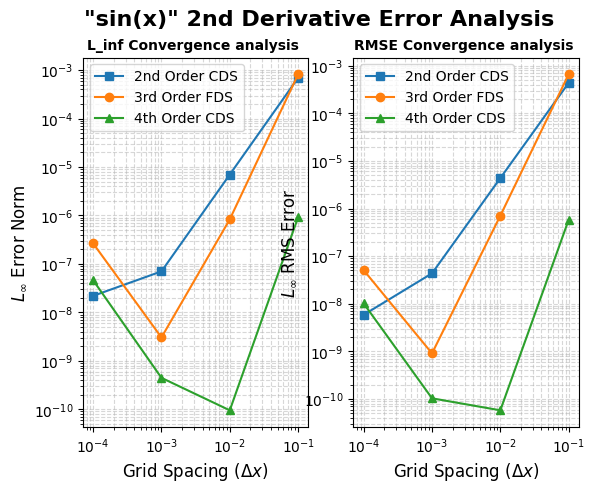

In [38]:
## ERROR comparison of the sin(x) with different schemes
plt.figure
## Plotting the Linf error
plt.subplot(1, 2, 1) # Using a single plot for clarity, or keep (1,2,1) if adding more

# Plot with distinct markers, line styles, and labels
plt.loglog(delta_xs, Linf_hist_f1_a, 's-', label="2nd Order CDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, Linf_hist_f1_b, 'o-', label="3rd Order FDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, Linf_hist_f1_c, '^-', label="4th Order CDS", linewidth=1.5, markersize=6)

# Labels and Title
plt.xlabel(r'Grid Spacing ($\Delta x$)', fontsize=12)
plt.ylabel(r'$L_{\infty}$ Error Norm', fontsize=12)
plt.title('L_inf Convergence analysis ', fontsize=10, fontweight='bold')

# Grid and Legend
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='best', fontsize=10, frameon=True)



### plotting the RMSE
plt.subplot(1, 2, 2)

# Plot with distinct markers, line styles, and labels
plt.loglog(delta_xs, RMSE_hist_f1_a, 's-', label="2nd Order CDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, RMSE_hist_f1_b, 'o-', label="3rd Order FDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, RMSE_hist_f1_c, '^-', label="4th Order CDS", linewidth=1.5, markersize=6)

# Labels and Title
plt.xlabel(r'Grid Spacing ($\Delta x$)', fontsize=12)
plt.ylabel(r'$L_{\infty}$ RMS Error', fontsize=12)
plt.title('RMSE Convergence analysis ', fontsize=10, fontweight='bold')

# Grid and Legend
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='best', fontsize=10, frameon=True)



plt.suptitle('"sin(x)" 2nd Derivative Error Analysis ', fontsize=16, fontweight='bold')

plt.show()



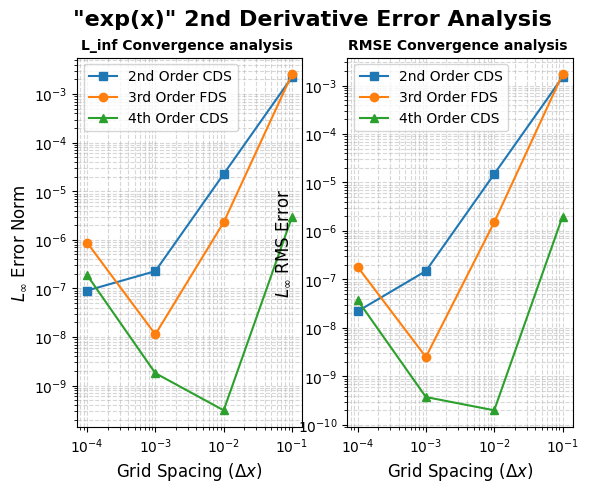

In [39]:
## ERROR comparison of the exp(x) with different schemes
plt.figure
## Plotting the Linf error
plt.subplot(1, 2, 1) # Using a single plot for clarity, or keep (1,2,1) if adding more

# Plot with distinct markers, line styles, and labels
plt.loglog(delta_xs, Linf_hist_f2_a, 's-', label="2nd Order CDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, Linf_hist_f2_b, 'o-', label="3rd Order FDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, Linf_hist_f2_c, '^-', label="4th Order CDS", linewidth=1.5, markersize=6)

# Labels and Title
plt.xlabel(r'Grid Spacing ($\Delta x$)', fontsize=12)
plt.ylabel(r'$L_{\infty}$ Error Norm', fontsize=12)
plt.title('L_inf Convergence analysis ', fontsize=10, fontweight='bold')

# Grid and Legend
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='best', fontsize=10, frameon=True)



### plotting the RMSE
plt.subplot(1, 2, 2)

# Plot with distinct markers, line styles, and labels
plt.loglog(delta_xs, RMSE_hist_f2_a, 's-', label="2nd Order CDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, RMSE_hist_f2_b, 'o-', label="3rd Order FDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, RMSE_hist_f2_c, '^-', label="4th Order CDS", linewidth=1.5, markersize=6)

# Labels and Title
plt.xlabel(r'Grid Spacing ($\Delta x$)', fontsize=12)
plt.ylabel(r'$L_{\infty}$ RMS Error', fontsize=12)
plt.title('RMSE Convergence analysis ', fontsize=10, fontweight='bold')

# Grid and Legend
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='best', fontsize=10, frameon=True)



plt.suptitle('"exp(x)" 2nd Derivative Error Analysis ', fontsize=16, fontweight='bold')

plt.show()

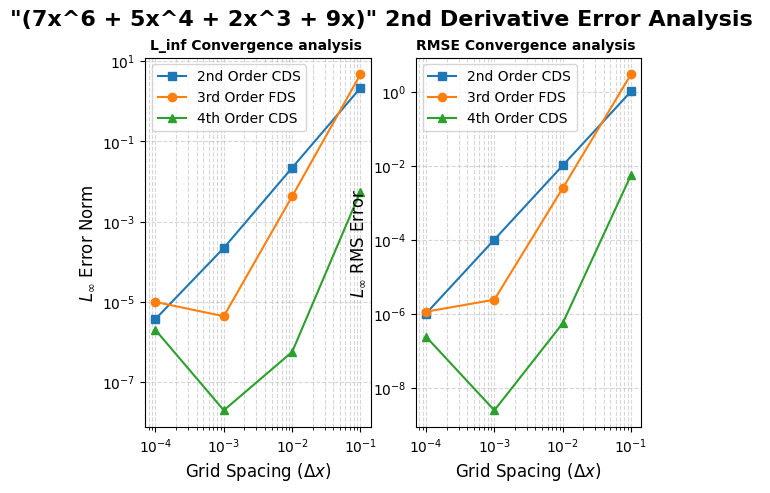

In [40]:
## ERROR comparison of the (7*x**6 + 5*x**4 + 2*x**3 + 9*x) with different schemes
plt.figure
## Plotting the Linf error
plt.subplot(1, 2, 1) # Using a single plot for clarity, or keep (1,2,1) if adding more

# Plot with distinct markers, line styles, and labels
plt.loglog(delta_xs, Linf_hist_f3_a, 's-', label="2nd Order CDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, Linf_hist_f3_b, 'o-', label="3rd Order FDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, Linf_hist_f3_c, '^-', label="4th Order CDS", linewidth=1.5, markersize=6)

# Labels and Title
plt.xlabel(r'Grid Spacing ($\Delta x$)', fontsize=12)
plt.ylabel(r'$L_{\infty}$ Error Norm', fontsize=12)
plt.title('L_inf Convergence analysis ', fontsize=10, fontweight='bold')

# Grid and Legend
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='best', fontsize=10, frameon=True)



### plotting the RMSE
plt.subplot(1, 2, 2)

# Plot with distinct markers, line styles, and labels
plt.loglog(delta_xs, RMSE_hist_f3_a, 's-', label="2nd Order CDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, RMSE_hist_f3_b, 'o-', label="3rd Order FDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, RMSE_hist_f3_c, '^-', label="4th Order CDS", linewidth=1.5, markersize=6)

# Labels and Title
plt.xlabel(r'Grid Spacing ($\Delta x$)', fontsize=12)
plt.ylabel(r'$L_{\infty}$ RMS Error', fontsize=12)
plt.title('RMSE Convergence analysis ', fontsize=10, fontweight='bold')

# Grid and Legend
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='best', fontsize=10, frameon=True)



plt.suptitle('"(7x^6 + 5x^4 + 2x^3 + 9x)" 2nd Derivative Error Analysis ', fontsize=16, fontweight='bold')

plt.show()

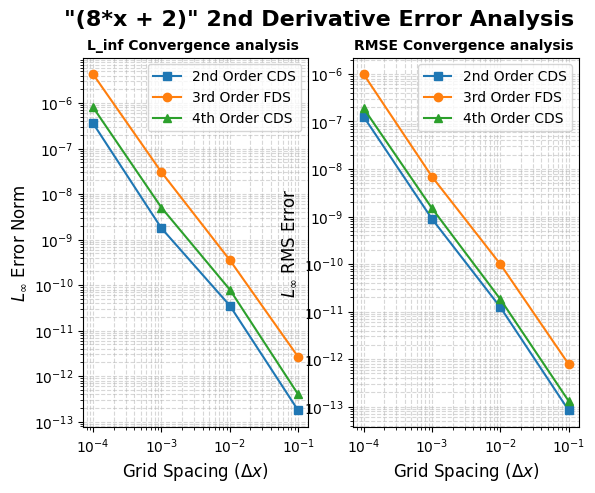

In [41]:
## ERROR comparison of the (8*x + 2) with different schemes
plt.figure
## Plotting the Linf error
plt.subplot(1, 2, 1) # Using a single plot for clarity, or keep (1,2,1) if adding more

# Plot with distinct markers, line styles, and labels
plt.loglog(delta_xs, Linf_hist_f4_a, 's-', label="2nd Order CDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, Linf_hist_f4_b, 'o-', label="3rd Order FDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, Linf_hist_f4_c, '^-', label="4th Order CDS", linewidth=1.5, markersize=6)

# Labels and Title
plt.xlabel(r'Grid Spacing ($\Delta x$)', fontsize=12)
plt.ylabel(r'$L_{\infty}$ Error Norm', fontsize=12)
plt.title('L_inf Convergence analysis ', fontsize=10, fontweight='bold')

# Grid and Legend
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='best', fontsize=10, frameon=True)



### plotting the RMSE
plt.subplot(1, 2, 2)

# Plot with distinct markers, line styles, and labels
plt.loglog(delta_xs, RMSE_hist_f4_a, 's-', label="2nd Order CDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, RMSE_hist_f4_b, 'o-', label="3rd Order FDS", linewidth=1.5, markersize=6)
plt.loglog(delta_xs, RMSE_hist_f4_c, '^-', label="4th Order CDS", linewidth=1.5, markersize=6)

# Labels and Title
plt.xlabel(r'Grid Spacing ($\Delta x$)', fontsize=12)
plt.ylabel(r'$L_{\infty}$ RMS Error', fontsize=12)
plt.title('RMSE Convergence analysis ', fontsize=10, fontweight='bold')

# Grid and Legend
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='best', fontsize=10, frameon=True)



plt.suptitle('"(8*x + 2)" 2nd Derivative Error Analysis ', fontsize=16, fontweight='bold')

plt.show()